In [ ]:
!pip install openpyxl

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 데이터 읽어오기 및 전처리</mark></b></span><br><br>

<b>[변수 및 환경 설정]</b><br>
• 아무것도 건들지 않은 파일 변수 <b>raw</b>, 문제 있는 수집세션만 삭제한 거 <b>not_processed</b>, 전처리 다한거 <b>df</b><br>
• <b>datasets 하위폴더</b> 만들고 내부에 데이터 전부 넣고 코드 시작<br>
• <b>첫 두 개의 데이터 파일은 수집시간 잘못됨</b> - 이거 삭제하는 것까지 <b>not_processed</b><br><br>

<span style="font-size: 24px;"><b><mark>📌 df 처리</mark></b></span><br><br>

<b>[결측치 및 0값 처리 로직]</b><br>
• <b>로직: viewer_count가 0인 것</b>은 확실한 결측치(0.02%) 차지하므로 <b>MCAR로 판단하고 선형보간</b><br>
• <b>chat_count가 0인 것들 처리</b>는 <b>['user_id', 'run_id']</b>로 묶은 세션 전부가 0인 것들은 <b>일단 삭제</b> (658개 row 삭제)<br>
• <b>avg_msg_len이 0인 것</b>은 전부 chat이 없어서 발생 -> <b>0으로 채워넣음</b><br><br>

<b>[세션 정보 및 결측 특성]</b><br>
• 세션(스트리머, 수집시간)은 <b>총 180개</b>이다. 요일은 <b>6일간 조사</b> 수집시간 (17~19), (20~22), (23~01) 세 번<br>
• 세션 시작될 때마다 <b>delta값이 불가피하게 결측됨</b>, delta 180개 결측은 당연함<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b> 제일 중요한 데이터 특성: 심하게 skewed된 데이터셋이다. 웬만하면 log를 씌워서 분석</b></span>
</div>

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 총 20개의 파일이 있고 파일의 특성상 
# 내부에 시간대는 연속되지만 session별로 streamer가 연속되지 않는다.
# 일단 전부 읽어오고 추후 처리

# 해당 파일명 형태와 같은 모든 것들 폴더에서 읽어옴
def file_reading(dir, file_name):
    DATA_DIR = Path(dir)
    files = sorted(DATA_DIR.glob(file_name))

    if len(files) == 0:
        raise FileNotFoundError("*번째의 데이터파일 없음")
    frames = []

    for f in files:
        tmp = pd.read_excel(f)
        # 파일명도 새 column으로 저장
        tmp["source_file"] = f.name

        # 파일 내부에 run_id가 없거나 전부 비어 있으면 파일명에서 추출
        if "run_id" not in tmp.columns or tmp["run_id"].isna().all():
            m = re.search(r"Run_(\d+)_Features", f.name)
            tmp["run_id"] = int(m.group(1)) if m else np.nan

        frames.append(tmp)

    raw = pd.concat(frames, ignore_index=True)
    meta_data = pd.DataFrame({"loaded_file_cnt":[len(files)], 
                   "row_cnt": [len(raw)],
                   "column_cnt" : [raw.shape[1]]})
    return raw , meta_data

raw, meta_data = file_reading("./datasets","Run_*_Features.xlsx")

# 파일 20개 읽음, row 20519개, column 18개
print(meta_data)
print(raw.head(3))


   loaded_file_cnt  row_cnt  column_cnt
0               20    20519          18
   feature_id  broad_no           minute_ts                           user_id  \
0        3988  18339168 2026-04-13 14:27:00  4ebef1eb4194611996dc38abf1d226d1   
1        3989  18339168 2026-04-13 14:28:00  4ebef1eb4194611996dc38abf1d226d1   
2        3990  18339168 2026-04-13 14:29:00  4ebef1eb4194611996dc38abf1d226d1   

  category_id  viewer_count_last  chat_count  unique_chatters  avg_msg_len  \
0        talk              883.0          30               20     11.83330   
1        talk              883.0          36               16     22.33330   
2        talk              878.0          39               18      7.84615   

   repeat_msg_ratio  new_chatter_ratio  chat_per_viewer  delta_viewer_1m  \
0          0.066667           1.000000         0.033975              NaN   
1          0.083333           0.437500         0.040770              0.0   
2          0.153846           0.388889         0.04441

In [ ]:
# raw는 아무것도 안건든 데이터
df = raw.copy()

# EC2 서버의 수집시간 보정
df["minute_ts"] = pd.to_datetime(df["minute_ts"], errors="coerce")
df["minute_ts"] = df["minute_ts"] + pd.Timedelta(hours= 9)

numeric_cols = [
    "viewer_count_last",
    "chat_count",
    "unique_chatters",
    "avg_msg_len",
    "repeat_msg_ratio",
    "new_chatter_ratio",
    "chat_per_viewer",
    "delta_viewer_1m",
    "delta_chat_1m"
]

# 수집된 수치형 데이터 혹시나 모를 문제 위해 점검
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 순서대로 정렬
df = df.sort_values(
    ["run_id", "user_id", "minute_ts"]
).reset_index(drop=True)

In [5]:
df.describe()

,feature_id,broad_no,minute_ts,viewer_count_last,chat_count,unique_chatters,avg_msg_len,repeat_msg_ratio,new_chatter_ratio,chat_per_viewer,delta_viewer_1m,delta_chat_1m,run_id,created_at,updated_at
count,20519.000000,2.051900e+04,20519,20515.000000,20519.000000,20519.000000,18748.000000,20519.000000,20519.000000,20519.000000,20310.000000,20315.000000,20519.000000,20519,20519
mean,14247.000000,1.839496e+07,2026-04-17 02:06:15.123543808,1654.865854,48.176373,26.371656,10.636039,0.154413,0.112141,0.048502,-0.932546,-0.083633,38.594815,2026-04-16 18:09:10.518982656,2026-04-16 18:09:10.518982656
min,3988.000000,1.829692e+07,2026-04-13 23:27:00,62.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-18657.000000,-930.000000,29.000000,2026-04-13 16:28:01,2026-04-13 16:28:01
25%,9117.500000,1.836887e+07,2026-04-15 17:35:00,399.000000,7.000000,5.000000,7.382690,0.000000,0.000000,0.011566,-6.000000,-9.000000,34.000000,2026-04-15 10:00:42,2026-04-15 10:00:42
50%,14247.000000,1.839204e+07,2026-04-16 23:12:00,656.000000,24.000000,15.000000,9.323530,0.093023,0.058824,0.030056,0.000000,0.000000,39.000000,2026-04-16 16:00:54,2026-04-16 16:00:54
75%,19376.500000,1.842588e+07,2026-04-18 18:44:00,1318.000000,58.000000,32.000000,11.905150,0.275000,0.142857,0.062938,5.000000,9.000000,43.000000,2026-04-18 10:00:59,2026-04-18 10:00:59
max,24506.000000,1.845476e+07,2026-04-20 01:00:00,64772.000000,1076.000000,713.000000,104.306000,1.000000,1.000000,1.233240,2649.000000,747.000000,48.000000,2026-04-19 16:00:43,2026-04-19 16:00:43
std,5923.469423,3.357872e+04,NaN,4351.120073,76.151386,38.677676,6.540862,0.179632,0.177882,0.062421,186.171682,47.307126,5.558913,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20519 entries, 0 to 20518
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   feature_id         20519 non-null  int64         
 1   broad_no           20519 non-null  int64         
 2   minute_ts          20519 non-null  datetime64[ns]
 3   user_id            20519 non-null  object        
 4   category_id        20519 non-null  object        
 5   viewer_count_last  20515 non-null  float64       
 6   chat_count         20519 non-null  int64         
 7   unique_chatters    20519 non-null  int64         
 8   avg_msg_len        18748 non-null  float64       
 9   repeat_msg_ratio   20519 non-null  float64       
 10  new_chatter_ratio  20519 non-null  float64       
 11  chat_per_viewer    20519 non-null  float64       
 12  delta_viewer_1m    20310 non-null  float64       
 13  delta_chat_1m      20315 non-null  float64       
 14  run_id

In [ ]:
# 설계한 수집시간 (17-19), (20-22), (23-01)시에 수집되지 않은 것 거르기 위한 코드

# run_id를 기준으로 그룹화하여 시작 시간(min)과 종료 시간(max) 추출
grouped = df.groupby('run_id')['minute_ts'].agg(['min', 'max']).reset_index()

# 조건에 맞게 포맷팅하는 함수 정의
def format_time_range(row):
    run_id = row['run_id']
    start = row['min']
    end = row['max']
    
    day = start.day
    
    # 시작 시간 파싱
    start_ampm = "오후" if start.hour >= 12 else "오전"
    start_hour = start.hour % 12 or 12
    start_min = f" {start.minute}분" if start.minute > 0 else ""
    
    # 종료 시간 파싱
    end_ampm = "오후" if end.hour >= 12 else "오전"
    end_hour = end.hour % 12 or 12
    end_min = f" {end.minute}분" if end.minute > 0 else ""
    
    # 시작 시간 문자열 조합
    start_str = f"{start_ampm} {start_hour}시{start_min}"
    
    # 종료 시간 문자열 조합 (시작과 끝의 오전/오후가 같으면 뒤쪽 생략)
    if start_ampm == end_ampm:
        end_str = f"{end_hour}시{end_min}"
    else:
        end_str = f"{end_ampm} {end_hour}시{end_min}"
        
    return f"{run_id} -> {day}일 {start_str} ~ {end_str}"

# 데이터프레임에 함수 적용 및 출력
for index, row in grouped.iterrows():
    print(format_time_range(row))

29 -> 13일 오후 11시 27분 ~ 오전 1시 27분
30 -> 14일 오전 2시 ~ 2시 30분
31 -> 14일 오후 5시 ~ 7시 1분
32 -> 14일 오후 8시 ~ 10시 1분
33 -> 14일 오후 11시 ~ 오전 1시
34 -> 15일 오후 5시 ~ 7시
35 -> 15일 오후 8시 ~ 10시
36 -> 15일 오후 11시 ~ 오전 1시
37 -> 16일 오후 5시 ~ 7시 1분
38 -> 16일 오후 8시 ~ 10시
39 -> 16일 오후 11시 ~ 오전 1시
40 -> 17일 오후 5시 ~ 7시
41 -> 17일 오후 8시 ~ 10시
42 -> 17일 오후 11시 ~ 오전 1시
43 -> 18일 오후 5시 ~ 7시
44 -> 18일 오후 8시 ~ 10시
45 -> 18일 오후 11시 ~ 오전 1시
46 -> 19일 오후 5시 ~ 7시
47 -> 19일 오후 8시 ~ 10시
48 -> 19일 오후 11시 ~ 오전 1시


In [4]:
# 초기에 29,30 데이터 파일은 EC2 서버 불안정성 때문에
# 설정한 시간과 완전히 다른 시간에서 데이터가 수집되어 제거 후 진행
df = df[df["run_id"] != 29]
df = df[df["run_id"] != 30]

In [ ]:
# 0 결측치처리는 신중히 해야하므로 처리전 파일 저장
not_processed = df.copy()

print(f"data (행,열):  {df.shape[0], df.shape[1]}")
print("======전체 결측치 관찰======")
print(df.isna().sum(),end = "\n\n")
print(f"총 처리해야 할 결측치는 {df.isna().sum().sum()}")
print(f"viewer가 0인 것: {len(df[df['viewer_count_last'] == 0])}")
print(f"chat이   0인 것: {len(df[df['chat_count'] == 0])}")
print(f"결정된 결측 비율 : {round(df['viewer_count_last'].isnull().sum()/len(df)*100,2)}%")

# 33,34, 38, 48 file에서 시청자 수 결측치 발견
vcnt = df.loc[df["viewer_count_last"].isnull()].index.tolist()
for idx in vcnt:
    print(f"위치 {df.loc[idx]['run_id']}", end=" ")

data (행,열):  (19116, 18)
======전체 결측치 관찰======
feature_id              0
broad_no                0
minute_ts               0
user_id                 0
category_id             0
viewer_count_last       4
chat_count              0
unique_chatters         0
avg_msg_len          1736
repeat_msg_ratio        0
new_chatter_ratio       0
chat_per_viewer         0
delta_viewer_1m       189
delta_chat_1m         184
run_id                  0
created_at              0
updated_at              0
source_file             0
dtype: int64

총 처리해야 할 결측치는 2113
viewer가 0인 것: 0
chat이   0인 것: 1736
결정된 결측 비율 : 0.02%
위치 33 위치 34 위치 38 위치 48 

In [ ]:
# avg_msg_len이 NaN으로 결측된 이유가 chat_count가 0인거로 인한것으로 완전히 설명가능함
df["avg_msg_len"] = df["avg_msg_len"].fillna(0)

# 확실한 결측치는 viewer_count가 0인 것으로 판단하고 
# 전체의 0.02%를 차지하기 때문에 user_id별로 묶은 뒤, 선형 보간 -> 앞채우기 -> 뒤채우기 순서로 연속 적용(MCAR처리)
df['viewer_count_last'] = df.groupby(['user_id','run_id'])['viewer_count_last'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

# 처리완료
print(df['viewer_count_last'].isnull().sum())
print(len(df))

0
19116


In [121]:
df['delta_viewer_1m'] = df.groupby(['user_id', 'run_id'])['viewer_count_last'].diff()
df['delta_chat_1m'] = df.groupby(['user_id', 'run_id'])['chat_count'].diff()

# 확인용 출력
print(df['delta_viewer_1m'].isnull().sum())
print(df['delta_chat_1m'].isnull().sum())

# 180개로 delta값이 유지되는데 이는 우리가 수집할 떄마다 user을 새롭게 수집하기에
# 섹터가 총 180개 수집했다는 의미로 해석하고 자연스러운 결측이다. 처리해줄 필요없음

180
180


In [ ]:

all_zero_runs = df.groupby(['user_id', 'run_id'])['chat_count'].apply(lambda x: (x == 0).all()).reset_index(name='전체_0_여부')

# 0이 연속되는 구간의 블록 구하기
is_zero = df['chat_count'] == 0
blocks = (is_zero != is_zero.shift()).cumsum()

# 블록별 상세 정보 추출 (user_id 추가)
# 어떤 유저의 데이터인지 알아야 정확한 매칭이 가능하므로 user_id를 추가로 추출
block_details = df[is_zero].groupby(blocks).agg(
    user_id=('user_id', 'first'),            # 해당 블록의 user_id 
    연속_길이=('chat_count', 'size'),          # 해당 블록의 행 개수 (길이)
    시작_run_id=('run_id', 'first'),         # 해당 블록의 첫 번째 run_id
    종료_run_id=('run_id', 'last')           # 해당 블록의 마지막 run_id
).reset_index(drop=True)                     # 불필요한 blocks 인덱스 제거

# 블록 상세 정보에 '전체_0_여부' 병합 (Mapping)
# user_id와 시작_run_id를 기준으로 판별 결과를 테이블 옆에 붙여줍니다.
block_details = pd.merge(block_details, all_zero_runs, 
                         left_on=['user_id', '시작_run_id'], 
                         right_on=['user_id', 'run_id'], 
                         how='left').drop(columns=['user_id','run_id'])

# 문제가 되는 가장 긴 구간부터 확인하기 위해 내림차순 정렬
block_details = block_details.sort_values(by='연속_길이', ascending=False).reset_index(drop=True)

# 인덱스 이름 수정 (기존의 '연속된 0의 길이'는 컬럼으로 들어갔으므로, 단순 순번을 의미하도록 변경)
block_details.index.name = '순번'
block_details = block_details[block_details['연속_길이'] != 1]
print("=== 채팅 0 구간 연속 길이 및 run_id 전체 0 여부 ===")
print(block_details)

=== 채팅 0 구간 연속 길이 및 run_id 전체 0 여부 ===
     연속_길이  시작_run_id  종료_run_id  전체_0_여부
순번                                       
0      182         46         46     True
1      121         36         36     True
2      120         35         35    False
3      118         39         39     True
4      118         34         34     True
..     ...        ...        ...      ...
152      2         43         43    False
153      2         40         40    False
154      2         43         43    False
155      2         43         43    False
156      2         43         43    False

[157 rows x 4 columns]


In [ ]:
# 연속되게 채팅이 0이 나온 것 중 동일한 ['user_id','run_id']묶음은 전체 삭제해도 무관
# 원본 df에서 전체가 0인 (user_id, run_id) 그룹을 찾아 제거하기
# transform을 사용해 각 행별로 자신이 속한 그룹이 모두 0인지 여부를 마스킹
is_all_zero_group = df.groupby(['user_id', 'run_id'])['chat_count'].transform(lambda x: (x == 0).all())

# 해당 마스크가 False인(전체가 0이 아닌) 데이터만 남겨서 df를 덮어씌웁니다.
df = df[~is_all_zero_group]

# 0이 연속되는 구간의 블록 구하기 (정제된 df 기준)
is_zero = df['chat_count'] == 0
blocks = (is_zero != is_zero.shift()).cumsum()

# 블록별 상세 정보 추출
block_details = df[is_zero].groupby(blocks).agg(
    user_id=('user_id', 'first'),            # 해당 블록의 user_id 
    연속_길이=('chat_count', 'size'),          # 해당 블록의 행 개수 (길이)
    시작_run_id=('run_id', 'first'),         # 해당 블록의 첫 번째 run_id
    종료_run_id=('run_id', 'last')           # 해당 블록의 마지막 run_id
).reset_index(drop=True)                     # 불필요한 blocks 인덱스 제거

# 문제가 되는 가장 긴 구간부터 확인하기 위해 내림차순 정렬
block_details = block_details.sort_values(by='연속_길이', ascending=False).reset_index(drop=True)

# 인덱스 이름 수정
block_details.index.name = '순번'

print("=== 채팅 0 구간 연속 길이 (전체 0인 run_id 원본에서 제외 완료) ===")
print(block_details)
print(f"원본에서 지금까지 얼마나 삭제? : {len(not_processed)-len(df)}")

=== 채팅 0 구간 연속 길이 (전체 0인 run_id 원본에서 제외 완료) ===
                              user_id  연속_길이  시작_run_id  종료_run_id
순번                                                                
0    123cf2a78842d677e66ec57f3e3039c2     63         37         37
1    123cf2a78842d677e66ec57f3e3039c2     47         37         37
2    df434464f7e4802bee47c4b9c88331f7     28         40         40
3    4f0e2fbfad9960eee61770e144b820b3     26         44         44
4    df434464f7e4802bee47c4b9c88331f7     20         43         43
..                                ...    ...        ...        ...
385  714205d014f45e311dcfdafcf9e7400f      1         37         37
386  714205d014f45e311dcfdafcf9e7400f      1         37         37
387  714205d014f45e311dcfdafcf9e7400f      1         37         37
388  714205d014f45e311dcfdafcf9e7400f      1         37         37
389  aed9d6557bebfb21ab3d081b862cdd2d      1         48         48

[390 rows x 4 columns]
원본에서 지금까지 얼마나 삭제? : 658


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 데이터 읽어오기 및 전처리</mark></b></span><br><br>

<span style="font-size: 20px;"><b>1. 목적:</b></span> <b>전체 세션 중에 채팅이 있는 정도를 구하고(0 chat) 해당 세션의 비율이 어느정도인지를 보이기</b><br><br>

<b>[히스토그램 및 박스플롯 시각화]</b><br>
• df에서 0값이 존재하는 것 중에 <b>0이 아닌 챗의 비율을 구하고</b><br>
• 해당 비율을 띄고 있는 <b>['user_id', 'run_id']의 묶음 수를 그래프로 그림</b><br>
• <b>히스토그램</b>은 bin수 조절 위해 <b>소수점 버림</b>, <b>boxplot</b>은 <b>소수점 유지한채로 그림</b><br><br>

<span style="color: #e53e3e; font-size: 18px;"><b> 결론: 60%의 세션이 전부 채팅이 있었다. skewed정도가 심하고 outlier가 일부 존재</b></span>
</div>

60.1%의 비율로 0 chat 없는 채팅 활발한 방송


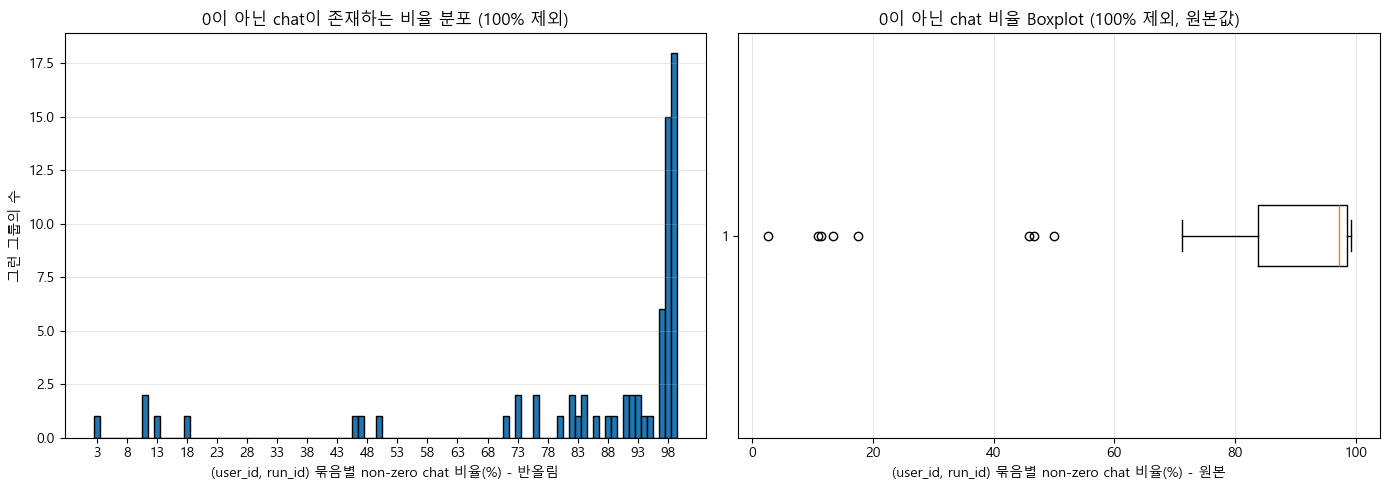

In [ ]:
# (user_id, run_id)별로 "0이 아닌 chat 비율(%)" 계산 - 원본(소수점 유지)
nonzero_percent_raw = (
    df.groupby(['user_id', 'run_id'])['chat_count']
      .apply(lambda s: (s.ne(0).mean() * 100))
)

# hist용: 반올림한 정수 버전
nonzero_percent_round = nonzero_percent_raw.round().astype(int)

# 100% (= 0 chat이 한 번도 없는 그룹) 비율 출력
freq_100 = (nonzero_percent_round.eq(100).mean() * 100).round(1)
print(f"{freq_100:.1f}%의 비율로 0 chat 없는 채팅 활발한 방송")

# 100% 제외한 plotting용 데이터
hist_data = nonzero_percent_round[nonzero_percent_round != 100]
box_data  = nonzero_percent_raw[nonzero_percent_raw != 100]

# 한국어 폰트 설정 및 -기호, 경고문 안 뜨게 설정
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'MalGun Gothic'
plt.rcParams['axes.unicode_minus'] = False 


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram: 반올림된 값 사용
# 각 값이 정수 percent이므로 bin도 정수 간격으로 맞춤
bins = np.arange(hist_data.min() - 0.5, hist_data.max() + 1.5, 1)

axes[0].hist(hist_data, bins=bins, edgecolor='black')
axes[0].set_title('0이 아닌 chat이 존재하는 비율 분포 (100% 제외)')
axes[0].set_xlabel('(user_id, run_id) 묶음별 non-zero chat 비율(%) - 반올림')
axes[0].set_ylabel('그런 그룹의 수')

# x축 눈금이 너무 많으면 5 단위로만 표시
xticks = np.arange(int(hist_data.min()), int(hist_data.max()) + 1, 5)
axes[0].set_xticks(xticks)
axes[0].grid(axis='y', alpha=0.3)

# boxplot: 원본 소수점 비율 사용
axes[1].boxplot(box_data, vert=False)
axes[1].set_title('0이 아닌 chat 비율 Boxplot (100% 제외, 원본값)')
axes[1].set_xlabel('(user_id, run_id) 묶음별 non-zero chat 비율(%) - 원본')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 도출 결론 => 전체 중에
# 대부분의 표본이 0이 아닌 chat으로 존재하고 있지만 outlier일부존재

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 plotting 및 향후 프로젝트를 위해 df의 column 확장</mark></b></span><br><br>

<b>[로그 변환 변수 (Log Scale)]</b><br>
• <b>viewer_log:</b> viewer에 log(1+x) 씌움<br>
• <b>chat_log:</b> chat_count_last에 log(1+x) 씌움<br>
• <b>unique_log:</b> unique_chatters에 log 씌움<br><br>

<b>[차이 및 변화량 변수 (Gap & Delta)]</b><br>
• <b>viewer_chat_log_gap:</b> viewer-chat 간의 로그 차<br>
• <b>viewer_unique_log_gap:</b> viewer와 채팅 친 고유한 사람들 차<br>
• <b>chat_per_viewer_recalc:</b> -로 연산된 시청자수 채팅수 차이<br>
• <b>unique_delta_1m:</b> 고유한 채팅친 사람들의 변화량<br><br>

<b>[0 채팅 추적 및 시간 변수]</b><br>
• <b>zero_chat:</b> 채팅 안 쳤는지 여부 boolean<br>
• <b>zero_chat_run_length:</b> 0채팅 나올 때마다 갱신해서 <b>1씩 증가시킴</b> (ex. 연속되게 3분간 0이면 1, 2, 3)<br>
• <b>minute_idx:</b> 해당 세션에서 <b>지난 시간 표기</b><br><br>

<b>[세션 식별 및 요약 정보]</b><br>
• <b>session_id:</b> run_id와 user_id 결합 (<b>자주 사용하게 될 거여서 묶은 걸 새롭게 만들어 둠</b>)<br>
• <b>session_summary:</b> 세션 정보 요약 정리<br>
• <b>session_summary_10m:</b> <b>10분 이상 수집된 정보만 정상 수집으로 판단</b>하고 10분 필터링함 (대다수가 10분)
</div>

In [125]:
plot_df = df.sort_values(['user_id', 'run_id', 'minute_ts']).copy()

plot_df['viewer_log'] = np.log1p(plot_df['viewer_count_last'])
plot_df['chat_log'] = np.log1p(plot_df['chat_count'])
plot_df['unique_log'] = np.log1p(plot_df['unique_chatters'])

plot_df['viewer_chat_log_gap'] = plot_df['viewer_log'] - plot_df['chat_log']
plot_df['viewer_unique_log_gap'] = plot_df['viewer_log'] - plot_df['unique_log']

plot_df['zero_chat'] = plot_df['chat_count'].eq(0)
plot_df['minute_idx'] = plot_df.groupby(['user_id', 'run_id']).cumcount() + 1

plot_df['chat_per_viewer_recalc'] = np.where(
    plot_df['viewer_count_last'].gt(0),
    plot_df['chat_count'] / plot_df['viewer_count_last'],
    np.nan
)
plot_df['unique_delta_1m'] = (
    plot_df.groupby(['user_id', 'run_id'])['unique_chatters']
           .diff()
)


def run_length_bool(s):
    s = s.fillna(False).astype(bool)
    block = s.ne(s.shift()).cumsum()
    return s.groupby(block).cumcount().add(1).where(s, 0).astype(int)

plot_df['zero_chat_run_length'] = (
    plot_df.groupby(['user_id', 'run_id'])['zero_chat']
           .transform(run_length_bool)
)

# 중복 로우로 인한 n_sessions 과대계산 원천 차단을 위해 고유 session_id 생성
plot_df['session_id'] = plot_df['user_id'].astype(str) + '_' + plot_df['run_id'].astype(str)

session_summary = (
    plot_df.groupby(['user_id', 'run_id'])
           .agg(
               n=('minute_ts', 'size'),
               start_ts=('minute_ts', 'min'),
               end_ts=('minute_ts', 'max'),
               median_viewer=('viewer_count_last', 'median'),
               max_viewer=('viewer_count_last', 'max'),
               mean_chat=('chat_count', 'mean'),
               mean_unique=('unique_chatters', 'mean'),
               zero_chat_rate=('zero_chat', 'mean'),
               max_zero_run=('zero_chat_run_length', 'max'),
               median_gap=('viewer_chat_log_gap', 'median'),
               max_gap=('viewer_chat_log_gap', 'max')
           )
           .reset_index()
)

# bubble plot과 동일한 안정성 기준 유지
# 10분이상 수집된 세션 기준 분석
session_summary_10m = session_summary[session_summary['n'] >= 10].copy()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 개별변수의 분포를 재점검</mark></b></span><br><br>

<b>극도로 skewed</b>되어있음을 미리 체크했으므로 <b>log로 그래프를 그리는 것을 원칙</b>으로 한다.<br>
특히 <b>zero_chat_run_length</b>는 0값 자체가 정상채팅보다 적어 <b>0에서의 빈도수가 압도적으로 높아 log로 y scale을 조정</b>
</div>

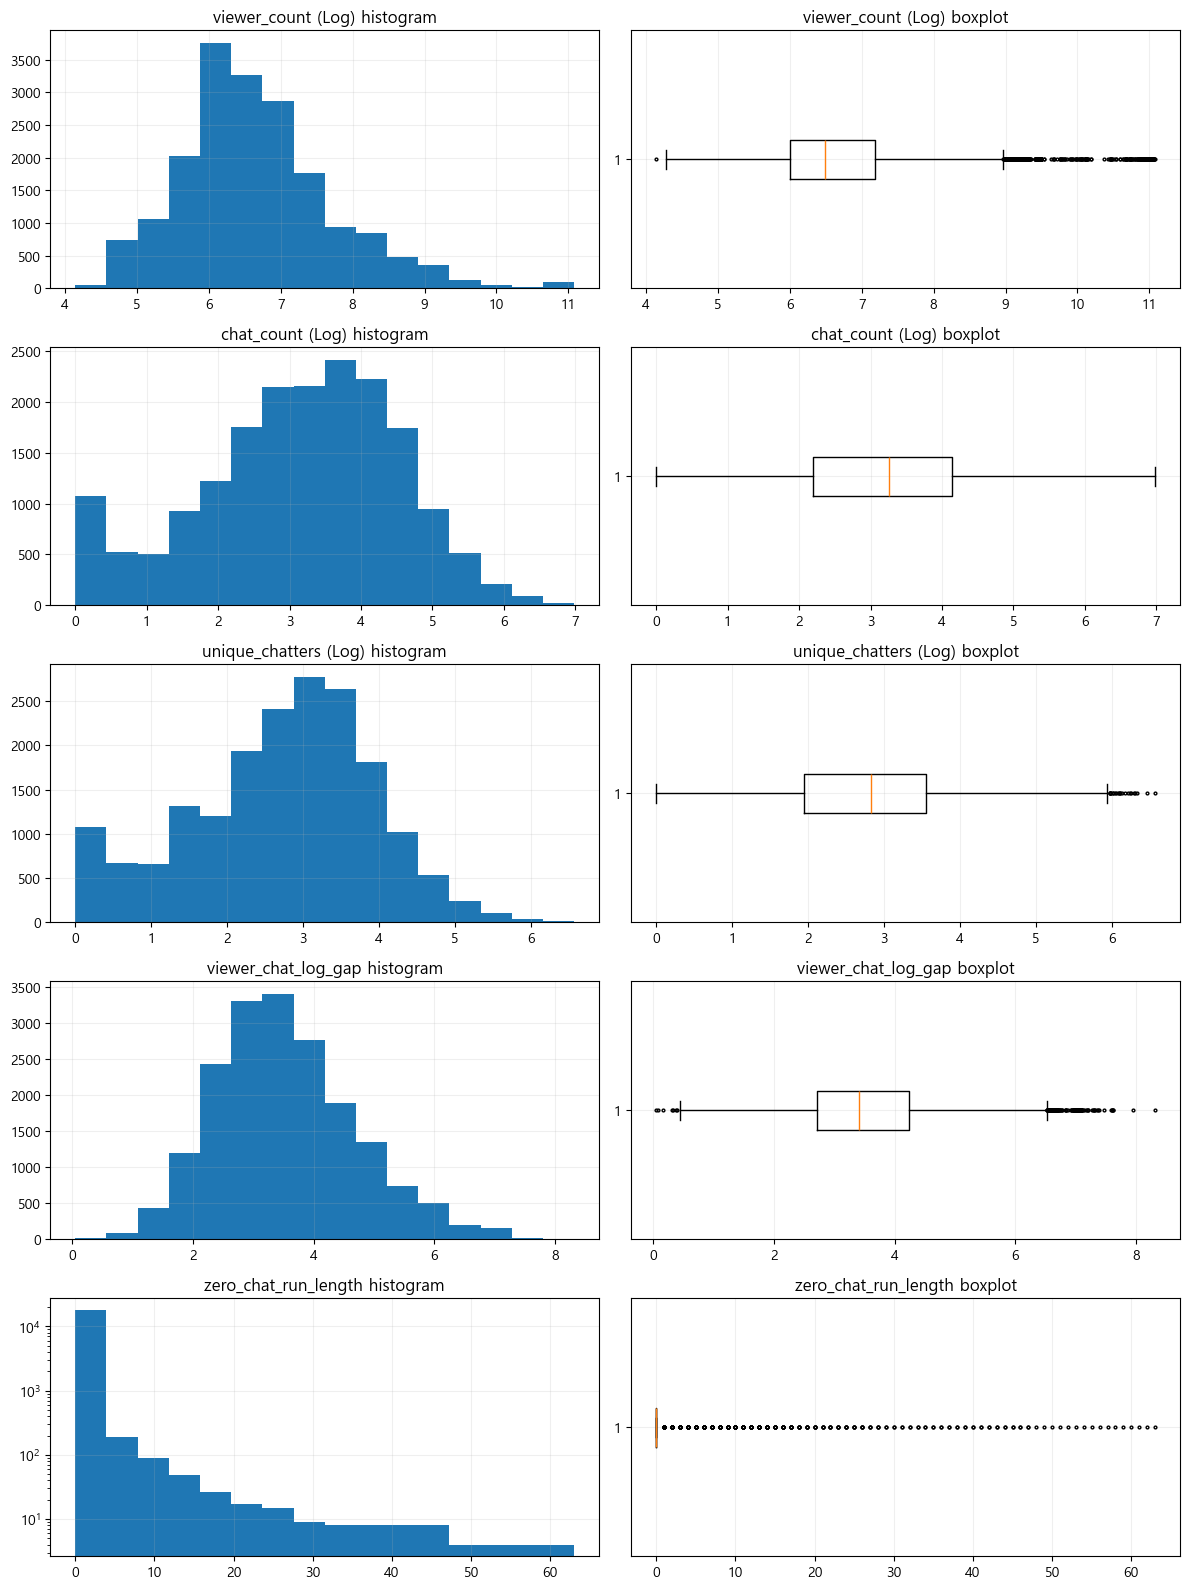

In [ ]:
#  단변량 분포 확인

plot_cols = [
    ('viewer_log', 'viewer_count (Log)'),
    ('chat_log', 'chat_count (Log)'),
    ('unique_log', 'unique_chatters (Log)'),
    ('viewer_chat_log_gap', 'viewer_chat_log_gap'),
    ('zero_chat_run_length', 'zero_chat_run_length')
]

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(12, 3.2 * len(plot_cols)))

for i, (col, title) in enumerate(plot_cols):
    s = plot_df[col].dropna()

    # zero_chat_run_length는 극도로 0에 쏠린 데이터이므로 y축을 log scale로 본다.
    if col == 'zero_chat_run_length':
        axes[i, 0].hist(s, bins='sturges', log=True)
    else:
        axes[i, 0].hist(s, bins='sturges')
        
    axes[i, 0].set_title(f'{title} histogram')
    axes[i, 0].grid(True, alpha=0.2)

    axes[i, 1].boxplot(s, flierprops={'marker': 'o', 'markersize': 2}, vert=False)
    axes[i, 1].set_title(f'{title} boxplot')
    axes[i, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 0 count 채팅의 분포 분석</mark></b></span><br><br>

<b>[각 그래프의 분석 의도]</b><br>
<b>1. 연속된 0 chat의 길이:</b> 막대그래프로 확인하며, 길이가 1인 경우가 압도적으로 많으므로 <b>log scale을 적용</b>합니다.<br>
<b>2. 분위수 별 0 chat 분포:</b> viewer_count_last를 전체적으로 <b>10분위로 나누어</b> 해당 분위수 별로 0 chat이 어느 정도 발생하는지 파악합니다.<br>
<b>3. 세션 시점(분) 별 0 chat 분포:</b> 선그래프를 통해 시점 별 분포 추이를 보고, 막대그래프로 <b>해당 분에 남아있는 session의 개수</b>를 함께 확인합니다.<br>
<b>4. zero_run 길이 구간 별 분석:</b> 연속된 0 chat(zero_run)의 길이 구간에 따른 <b>median viewer(중앙값 시청자 수)</b>를 분석합니다.<br><br>

<span style="color: #e53e3e;"><b> 핵심 참고: 데이터의 skew(비대칭 쏠림) 정도가 심하므로, 대표값으로 평균 대신 중앙값(median)을 사용합니다!</b></span>
</div>

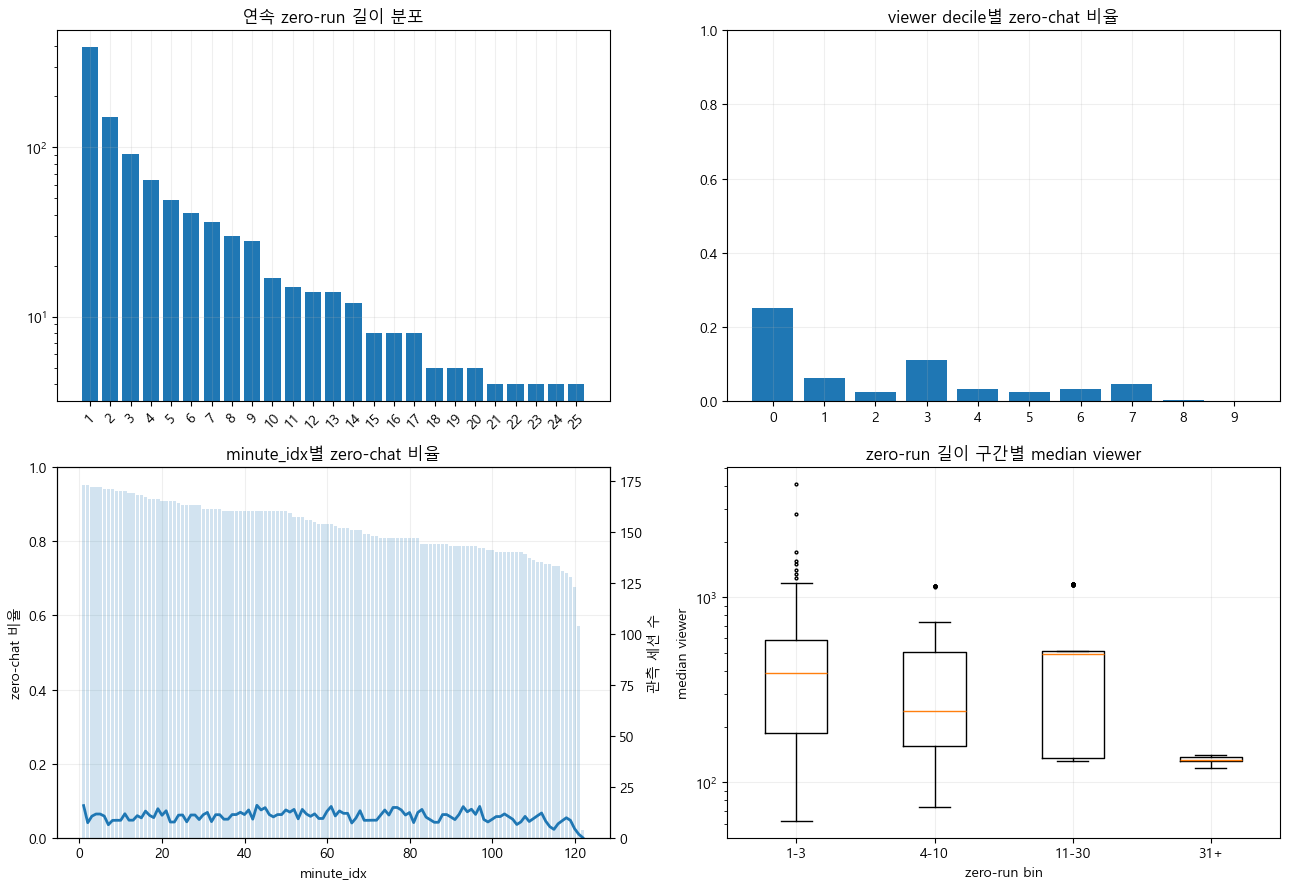

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 연속 zero-run 길이 분포
zero_runs = plot_df.loc[plot_df['zero_chat'], 'zero_chat_run_length']
dist = zero_runs.value_counts().sort_index().head(25)

axes[0, 0].bar(dist.index.astype(str), dist.values)
axes[0, 0].set_title('연속 zero-run 길이 분포')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.2)

# viewer 분위별 zero 비율
tmp = plot_df.dropna(subset=['viewer_count_last']).copy()
tmp['viewer_bin'] = pd.qcut(
    tmp['viewer_count_last'].rank(method='first'),
    q=10,
    labels=False,
    duplicates='drop'
)

zero_rate_by_bin = tmp.groupby('viewer_bin')['zero_chat'].mean()

axes[0, 1].bar(zero_rate_by_bin.index.astype(str), zero_rate_by_bin.values)
axes[0, 1].set_title('viewer decile별 zero-chat 비율')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, alpha=0.2)

# 세션 내 시점(minute_idx)별 zero-chat 비율 + 관측 세션 수
minute_zero = (
    tmp.groupby('minute_idx')
       .agg(
           zero_rate=('zero_chat', 'mean'),
           n_sessions=('run_id', 'size')
       )
       .reset_index()
)

ax1 = axes[1, 0]
ax2 = ax1.twinx()

ax1.plot(
    minute_zero['minute_idx'],
    minute_zero['zero_rate'],
    linewidth=2
)
ax1.set_title('minute_idx별 zero-chat 비율')
ax1.set_xlabel('minute_idx')
ax1.set_ylabel('zero-chat 비율')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.2)

ax2.bar(
    minute_zero['minute_idx'],
    minute_zero['n_sessions'],
    alpha=0.2
)
ax2.set_ylabel('관측 세션 수')

# zero-run 길이 구간별 median viewer
grouped_zero = (
    plot_df[plot_df['zero_chat']]
    .groupby(['user_id', 'run_id', 'zero_chat_run_length'])['viewer_count_last']
    .median()
    .reset_index()
)

grouped_zero['run_bin'] = pd.cut(
    grouped_zero['zero_chat_run_length'],
    bins=[0, 3, 10, 30, grouped_zero['zero_chat_run_length'].max()],
    labels=['1-3', '4-10', '11-30', '31+'],
    include_lowest=True
)

bp_data = []
labels = []

for label in ['1-3', '4-10', '11-30', '31+']:
    vals = grouped_zero.loc[grouped_zero['run_bin'] == label, 'viewer_count_last'].dropna().values
    if len(vals) > 0:
        bp_data.append(vals)
        labels.append(label)

axes[1, 1].boxplot(bp_data, labels=labels, flierprops={'marker': 'o', 'markersize': 2}, vert=True)
axes[1, 1].set_title('zero-run 길이 구간별 median viewer')
axes[1, 1].set_xlabel('zero-run bin')
axes[1, 1].set_ylabel('median viewer')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 viewer과 chat 간의 관계 분석</mark></b></span><br><br>

<b>[scatter가 아닌 hexbin을 쓴 이유]</b><br>
데이터가 너무 많아 일반적인 scatter로 분석 시 <b>데이터 밀집도를 제대로 파악하기 어렵기 때문</b>입니다.<br>
Hexbin은 <b>공간을 6각형 여러 개로 분할해 해당 공간의 밀도를 색깔로 나타내주어</b> 직관적인 파악이 가능합니다.<br><br>

<b>[각 그래프의 분석 의도]</b><br>
<b>1. viewer과 chat 간의 관계</b>를 보기 위한 그래프 (log scale 적용)<br>
<b>2. viewer과 unique_chatter 간의 관계</b>를 보는 그래프 (log scale 적용)<br>
<b>3. 1분 단위의 순간적인 변화량 확인:</b> 시청자가 급증/급감할 때 채팅량도 즉각적으로 반응하는지 파악하며, <b>상하위 극단치 1%를 제외한 상황에서의 동기화 패턴</b>을 봅니다.<br>
<b>4. 규모에 따른 격차 확인:</b> 채널의 규모(viewer)가 커질수록 <b>시청자 수와 채팅량 사이의 격차가 어떻게 변하는지</b> 확인합니다.
</div>

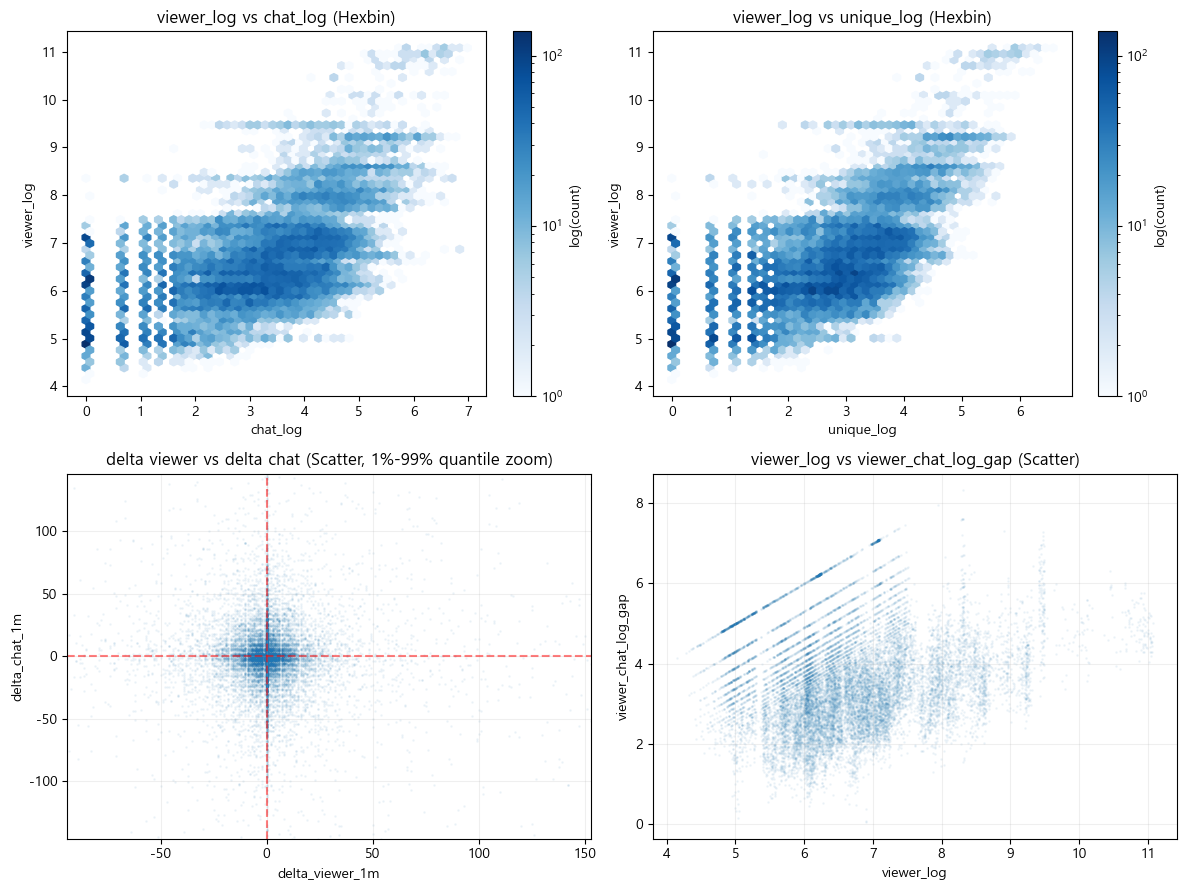

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 점 크기(s)와 투명도(alpha) 조정 (3, 4번 플롯용)
scatter_kwargs = {'s': 1, 'alpha': 0.05}

# viewer vs chat (Hexbin 적용 - bins='log' 옵션으로 옅은 이상치도 살림)
m = plot_df[['chat_log', 'viewer_log']].dropna()
hb1 = axes[0, 0].hexbin(m['chat_log'], m['viewer_log'], gridsize=50, cmap='Blues', mincnt=1, bins='log')
axes[0, 0].set_title('viewer_log vs chat_log (Hexbin)')
axes[0, 0].set_xlabel('chat_log')
axes[0, 0].set_ylabel('viewer_log')
fig.colorbar(hb1, ax=axes[0, 0], label='log(count)')

# viewer vs unique (Hexbin 적용 - bins='log' 옵션)
m = plot_df[['unique_log', 'viewer_log']].dropna()
hb2 = axes[0, 1].hexbin(m['unique_log'], m['viewer_log'], gridsize=50, cmap='Blues', mincnt=1, bins='log')
axes[0, 1].set_title('viewer_log vs unique_log (Hexbin)')
axes[0, 1].set_xlabel('unique_log')
axes[0, 1].set_ylabel('viewer_log')
fig.colorbar(hb2, ax=axes[0, 1], label='log(count)')

# delta viewer vs delta chat (Scatter 유지 + Quantile 기반 자동 줌인)
# 시각적 해석을 위해 상하위 1% 극단치는 축 범위에서 제외하고 중앙 98%만 표시
m = plot_df[['delta_viewer_1m', 'delta_chat_1m']].dropna()

# 상하위 1% 극단치를 제외한 98% 구간을 기준으로 축소
q01_v, q99_v = m['delta_viewer_1m'].quantile([0.01, 0.99])
q01_c, q99_c = m['delta_chat_1m'].quantile([0.01, 0.99])

axes[1, 0].scatter(m['delta_viewer_1m'], m['delta_chat_1m'], **scatter_kwargs)
axes[1, 0].axhline(0, linestyle='--', color='red', alpha=0.5)
axes[1, 0].axvline(0, linestyle='--', color='red', alpha=0.5)
axes[1, 0].set_title('delta viewer vs delta chat (Scatter, 1%-99% quantile zoom)')
axes[1, 0].set_xlabel('delta_viewer_1m')
axes[1, 0].set_ylabel('delta_chat_1m')
axes[1, 0].set_xlim(q01_v, q99_v)
axes[1, 0].set_ylim(q01_c, q99_c)
axes[1, 0].grid(True, alpha=0.2)

# viewer vs gap (Scatter 유지)
m = plot_df[['viewer_log', 'viewer_chat_log_gap']].dropna()
axes[1, 1].scatter(m['viewer_log'], m['viewer_chat_log_gap'], **scatter_kwargs)
axes[1, 1].set_title('viewer_log vs viewer_chat_log_gap (Scatter)')
axes[1, 1].set_xlabel('viewer_log')
axes[1, 1].set_ylabel('viewer_chat_log_gap')
axes[1, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b>📌 시각화 목적 및 분석 (시간 경과에 따른 세션 지표 변화)</b></span><br>

<br><br><b>[각 그래프의 분석 의도]</b><br>
<b>1. Surviving Sessions: viewer_count_last</b><br>
방송 시간이 경과함에 따라 <b>일반적인 시청자 수의 증감 추세</b>가 어떻게 흘러가는지 파악한다.<br>

<b>2. Surviving Sessions: chat_count</b><br>
방송 시간이 길어질수록 전체적인 <b>채팅 발생량(활성도)</b>이 유지되는지, 혹은 점차 식어가는지 확인한다.<br>

<b>3. Surviving Sessions: unique_chatters</b><br>
시간 흐름에 따라 <b>채팅에 참여하는 고유 시청자 수</b>의 변화를 보며, 시간이 지나도 다양한 사람들이 채팅에 참여하는지 소수만 남는지 파악한다.<br>

<b>4. Surviving Sessions: viewer_chat_log_gap</b><br>
방송 진행 시간에 따른 <b>시청자 규모 대비 채팅 참여 비율(격차)</b>의 흐름을 봅니다. 시간이 지날수록 눈팅 유저가 많아져 격차가 커지는지, 아니면 몰입도가 높아져 간극이 좁혀지는지 분석할 수 있다.
</div>

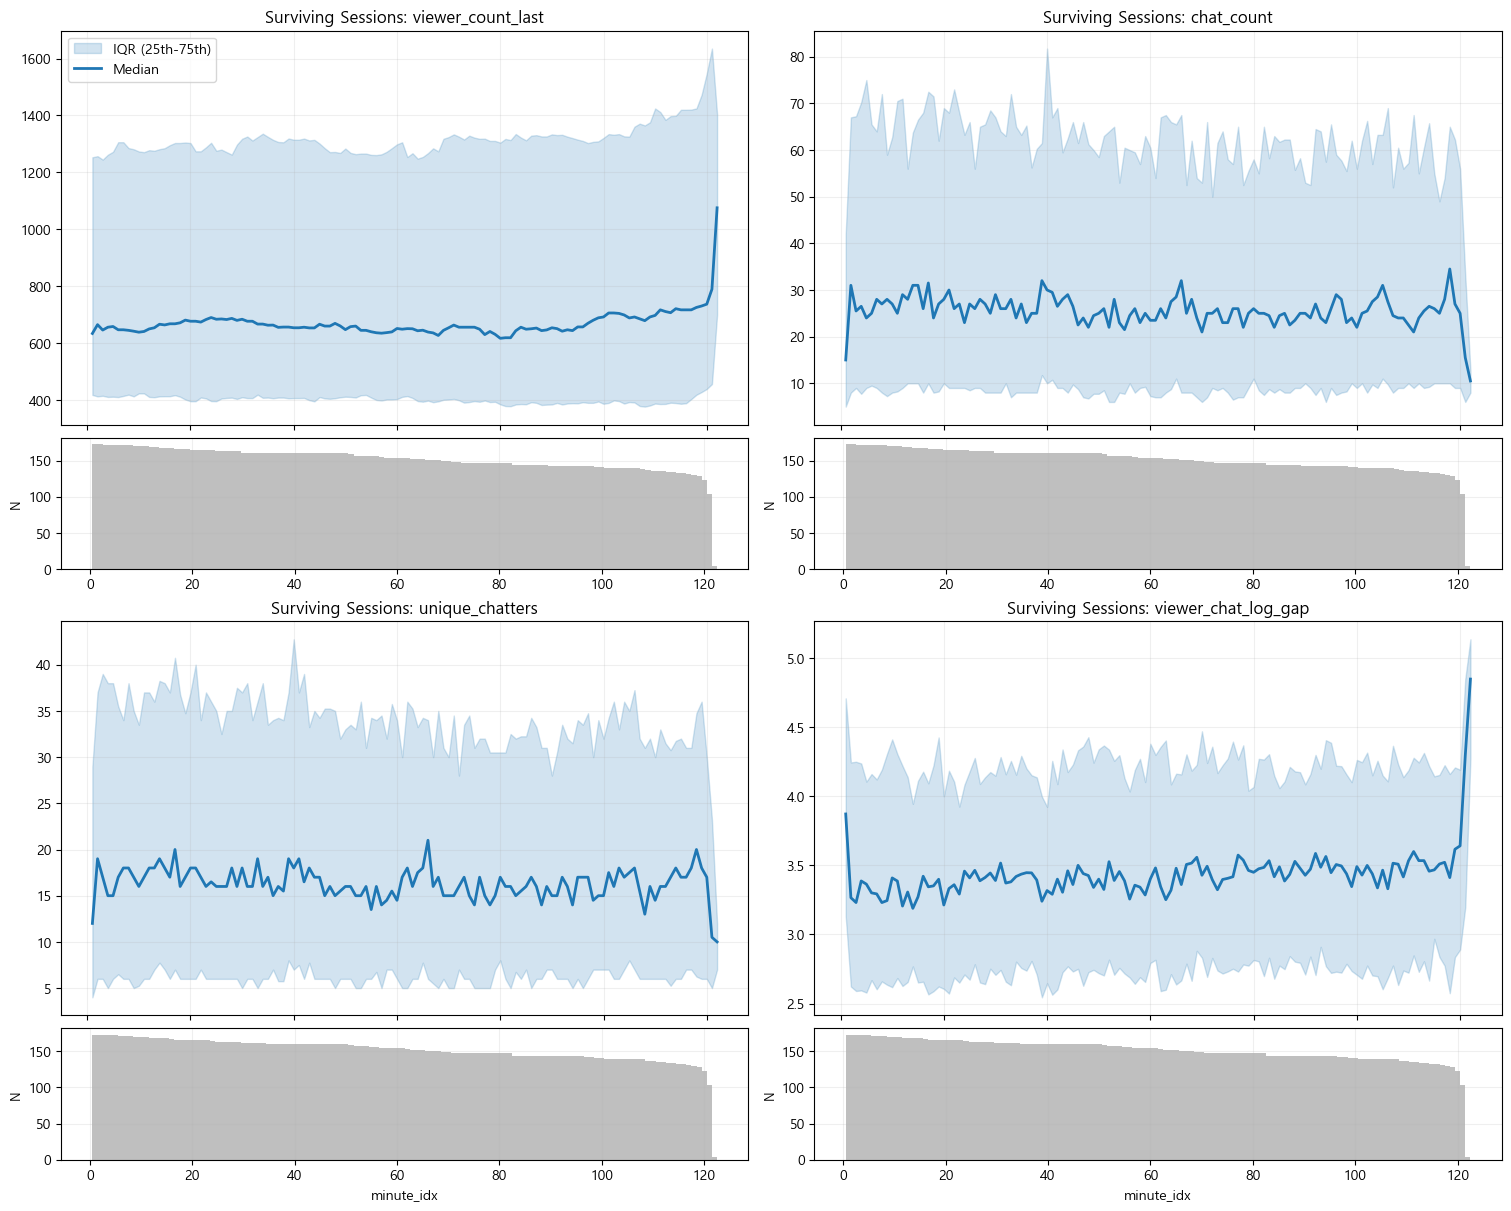

In [ ]:
# agg 시 size 대신 session_id의 nunique를 사용하여 완벽한 고유 세션 수 계산
agg = (
    plot_df.groupby('minute_idx')
           .agg(
               median_viewer=('viewer_count_last', 'median'),
               q25_viewer=('viewer_count_last', lambda x: x.quantile(0.25)),
               q75_viewer=('viewer_count_last', lambda x: x.quantile(0.75)),
               
               median_chat=('chat_count', 'median'),
               q25_chat=('chat_count', lambda x: x.quantile(0.25)),
               q75_chat=('chat_count', lambda x: x.quantile(0.75)),
               
               median_unique=('unique_chatters', 'median'),
               q25_unique=('unique_chatters', lambda x: x.quantile(0.25)),
               q75_unique=('unique_chatters', lambda x: x.quantile(0.75)),
               
               median_gap=('viewer_chat_log_gap', 'median'),
               q25_gap=('viewer_chat_log_gap', lambda x: x.quantile(0.25)),
               q75_gap=('viewer_chat_log_gap', lambda x: x.quantile(0.75)),
               
               n_sessions=('session_id', 'nunique') # 핵심 수정 부분
           )
           .reset_index()
)

fig, axes = plt.subplots(
    nrows=4, ncols=2, 
    figsize=(15, 12), 
    gridspec_kw={'height_ratios': [3, 1, 3, 1]},
    constrained_layout=True
)

metrics = [
    ('viewer', 'viewer_count_last'), 
    ('chat', 'chat_count'), 
    ('unique', 'unique_chatters'), 
    ('gap', 'viewer_chat_log_gap')
]

for i, (name, title) in enumerate(metrics):
    col = i % 2
    row_main = (i // 2) * 2
    row_supp = row_main + 1
    
    ax_main = axes[row_main, col]
    ax_supp = axes[row_supp, col]
    
    # 메인 패널
    ax_main.fill_between(
        agg['minute_idx'], agg[f'q25_{name}'], agg[f'q75_{name}'], 
        color='tab:blue', alpha=0.2, label='IQR (25th-75th)'
    )
    ax_main.plot(
        agg['minute_idx'], agg[f'median_{name}'], 
        color='tab:blue', linewidth=2, label='Median'
    )
    ax_main.set_title(f'Surviving Sessions: {title}')
    ax_main.grid(True, alpha=0.2)
    ax_main.tick_params(labelbottom=False)
    if i == 0:
        ax_main.legend(loc='upper left')
        
    # 서포트 패널
    ax_supp.bar(agg['minute_idx'], agg['n_sessions'], color='gray', alpha=0.5, width=1.0)
    ax_supp.set_ylabel('N', fontsize=9)
    ax_supp.grid(True, alpha=0.2)
    
    if row_supp == 3:
        ax_supp.set_xlabel('minute_idx')


plt.show()


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 세션 수준 뷰봇 의심군 탐색 Bubble Plot 시각화 논리</mark></b></span><br><br>

<b>[데이터 전처리 및 필터링]</b><br>
• <b>짧은 세션 노이즈 제거:</b> 데이터의 신뢰성을 확보하기 위해, 너무 짧게 진행되어 패턴을 파악하기 힘든 <b>10분 미만의 세션은 제외하고(n >= 10) 분석</b>을 진행한다.<br><br>

<b>[그래프 구성 요소 (4차원 데이터 시각화)]</b><br>
단순한 2차원 산점도를 넘어, <b>위치(X, Y), 크기, 색상</b>을 통해 4가지 지표를 동시에 분석합니다.<br>
• <b>X축 (median_viewer):</b> 세션의 <b>중앙값 시청자 수</b>를 의미하며, 방송 규모의 편차가 크므로 <b>로그 스케일(Log Scale)</b>을 적용해 넓은 범위를 한눈에 본다.<br>
• <b>Y축 (median_gap):</b> <b>시청자 수와 채팅량 간의 중앙값 격차</b>를 나타낸다. 뷰봇이 투입되었다면 시청자는 많으나 채팅이 없어 이 격차가 높게 나타난다.<br>
• <b>버블 크기 :</b> 세션 내에서 발생한 <b>최대 격차(max_gap)</b>를 나타낸다. (시각적 구분을 위해 30을 곱해 스케일링함). 원이 클수록 <b>순간적으로 시청자와 채팅의 괴리가 극심했던 구간</b>이 존재함을 의미함.<br>
• <b>버블 색상 :</b> <b>채팅이 아예 없었던 비율(zero_chat_rate)</b>을 나타낸다. 색상이 밝을수록(노란색에 가까울수록) 0 채팅 비율이 높다는 뜻이다.<br><br>

<b>[시각적 가이드 및 핵심 의심 세션 추출]</b><br>
• <b>저뷰어 주의 구간 분리:</b> X축 <b>100명 선에 시각적 가이드라인</b>을 그었다. 하꼬방(시청자가 적은 방)에서는 뷰봇이 없어도 자연스럽게 채팅이 없을 수 있으므로, <b>의미 있는 분석 구간과 노이즈 구간을 시각적으로 분리</b>하는 역할을 한다.<br>
• <b>Top 5 의심군 텍스트 강조:</b> 시청자 100명 이상인 유의미한 세션 중에서, <b>1) 채팅 없는 비율(zero_chat_rate)이 높고 2) 시청자-채팅 격차(median_gap)가 큰 최상위 5개 세션</b>을 찾아낸다. 이 5개 세션의 <b>`run_id`를 그래프 위에 직접 표기(Annotation)</b>하여 직관적으로 의심군을 특정할 수 있게 설계한다.<br><br>

<b>[데이터 검증]</b><br>
시각화가 끝난 후, <b>최대 격차(max_gap)와 연속 0채팅 최대 길이(max_zero_run)</b>를 기준으로 내림차순 정렬한 상위 10개 데이터를 표(DataFrame)로 출력하여 <b>실제 수치를 기반으로 한 번 더 크로스 체크</b>를 진행한다.
</div>

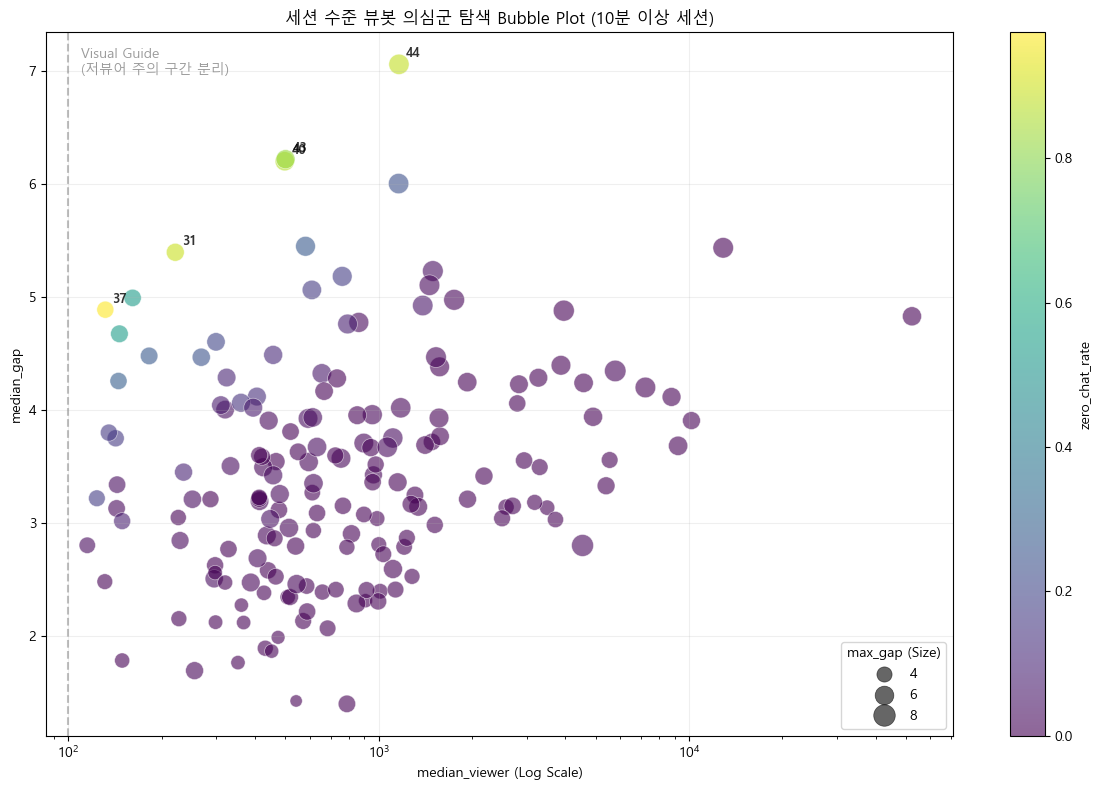

,user_id,run_id,n,start_ts,end_ts,median_viewer,max_viewer,mean_chat,mean_unique,zero_chat_rate,max_zero_run,median_gap,max_gap
117,b044e3a3b9259246bc92e863e7d3f3b8,42,61,2026-04-17 23:00:00,2026-04-18 00:00:00,4541.0,5055.0,325.032787,125.590164,0.016393,1,2.801675,8.315811
8,0b33823ac81de48d5b78a38cdbc0ab94,38,121,2026-04-16 20:00:00,2026-04-16 22:00:00,5789.0,25407.0,124.619835,73.223140,0.008264,1,4.344510,7.948738
33,2086f44c7b09a17cef6786f21389db3b,38,121,2026-04-16 20:00:00,2026-04-16 22:00:00,3951.0,4173.0,38.107438,26.966942,0.000000,0,4.877411,7.612831
111,aed9d6557bebfb21ab3d081b862cdd2d,48,120,2026-04-19 23:00:00,2026-04-20 00:59:00,1751.0,2086.0,14.975000,11.716667,0.008333,1,4.973279,7.466228
109,aed9d6557bebfb21ab3d081b862cdd2d,40,121,2026-04-17 17:00:00,2026-04-17 19:00:00,1495.0,1815.0,12.950413,8.619835,0.033058,1,5.227761,7.381502
110,aed9d6557bebfb21ab3d081b862cdd2d,42,120,2026-04-17 23:00:00,2026-04-18 00:59:00,1530.5,1710.0,19.108333,12.175000,0.008333,1,4.466328,7.326466
146,d2fb83a5db130bf4d273c981b82ca41f,46,121,2026-04-19 17:00:00,2026-04-19 19:00:00,1458.0,1595.0,9.264463,6.495868,0.016529,1,5.102573,7.309212
38,26ae7850ad5b6b09ca864d482dc7fa50,42,121,2026-04-17 23:00:00,2026-04-18 01:00:00,7241.0,8179.0,116.404959,76.950413,0.000000,0,4.198497,7.292882
83,7ce8032370ac5121dcabce7bad375ced,33,120,2026-04-14 23:00:00,2026-04-15 00:59:00,12898.5,13291.0,81.041667,54.808333,0.000000,0,5.433100,7.277632
134,c100f81959d1c17044be0541eed56f5b,39,19,2026-04-16 23:00:00,2026-04-16 23:18:00,1387.0,1430.0,14.842105,11.263158,0.052632,1,4.922896,7.198931


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# 짧은 세션 노이즈 제거 (10분 이상 세션만)
plot_data = session_summary[session_summary['n'] >= 10].copy()

# 버블 크기 스케일링
bubble_size = plot_data['max_gap'].fillna(0) * 30 

sc = ax.scatter(
    plot_data['median_viewer'],
    plot_data['median_gap'],
    s=bubble_size,
    c=plot_data['zero_chat_rate'].fillna(0),
    cmap='viridis',
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

ax.set_title('세션 수준 뷰봇 의심군 탐색 Bubble Plot (10분 이상 세션)')
ax.set_xlabel('median_viewer (Log Scale)') 
ax.set_ylabel('median_gap')
ax.set_xscale('log') 

# 시각적 가이드라인 (Threshold 아님)
ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
ax.text(110, ax.get_ylim()[1]*0.95, 'Visual Guide\n(저뷰어 주의 구간 분리)', color='gray', alpha=0.8)
ax.grid(True, alpha=0.2)

# 색상 범례 (zero_chat_rate)
cbar = plt.colorbar(sc, ax=ax, label='zero_chat_rate')


# 상위 의심 세션 Annotation
# 기준: 시청자 100명 이상 중 zero_chat_rate 최상위, 그 다음 median_gap 최상위 5개 추출

suspects = plot_data[plot_data['median_viewer'] >= 100].sort_values(
    ['zero_chat_rate', 'median_gap'], ascending=[False, False]
).head(5)

for _, row in suspects.iterrows():
    ax.annotate(
        f"{row['run_id']}",
        (row['median_viewer'], row['median_gap']),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=9,
        fontweight='bold', 
        color='black',
        alpha=0.8
    )


#  버블 크기(max_gap) 범례
# 면적(s)으로 들어간 값을 다시 30으로 나누어 원래의 max_gap 수치로 복원하여 표시
handles, labels = sc.legend_elements(prop="sizes", alpha=0.6, num=4, func=lambda s: np.round(s / 30, 1))
ax.legend(handles, labels, loc="lower right", title="max_gap (Size)")

plt.tight_layout()
plt.show()

display(plot_data.sort_values(['max_gap', 'max_zero_run'], ascending=False).head(10))

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 EDA 2 - Correlation Summary (설명변수 상관관계 분석)</mark></b></span><br><br>

<b>[코드의 목적 및 시각화 논리]</b><br>
• <b>수업자료 EDA 2에 맞춰 설명변수 간 관계를 표로 정리</b>하는 것이 주 목적.<br>
• 분석에 사용될 8개의 핵심 변수(viewer_log, delta 등)를 묶어 <b>전체 상관계수 행렬(Correlation Matrix)</b>을 1차적으로 계산하여 전체적인 흐름을 파악한다.<br>
• 그 후 방대한 행렬 속에서 직관적인 해석을 돕기 위해, <b>가장 유의미하고 중요한 6개의 변수 쌍(pair)만 따로 추출</b>하여 `corr_focus`라는 요약 데이터프레임으로 정리한다.<br><br>

<b>[Pearson / Spearman 둘 다 확인하는 이유 (교차 검증)]</b><br>
우리의 데이터는 <b>극도로 Skewed(비대칭) 되어 있고 이상치(Outlier)가 존재하는 특성</b>을 가지고 있다. 따라서 단일 지표만 맹신할 수 없으므로, 서로 다른 접근 방식을 가진 두 지표를 비교 분석해야 한다.<br><br>
• <b>Pearson (피어슨 상관계수):</b> 두 변수가 얼마나 일정한 비율로 <b>'선형적(직선) 비례 관계'</b>를 가지는지 측정한다. 수치 자체의 크기를 반영하므로 이상치나 쏠림 현상에 민감하게 반응한다.<br>
• <b>Spearman (스피어만 상관계수):</b> 수치 자체가 아닌 <b>'값들의 순위(Rank)'</b>를 기준으로 <b>'단조적 비례 관계'</b>를 측정한다. 순위 기반이므로 이상치나 극단적인 Skewness에 훨씬 강건(Robust)한 결과를 보여준다.<br>
</div>

In [ ]:
# - 수업자료 EDA 2에 맞춰 설명변수 간 관계를 표로 정리

corr_cols = [
    'viewer_log',
    'chat_log',
    'unique_log',
    'delta_viewer_1m',
    'delta_chat_1m',
    'viewer_chat_log_gap',
    'viewer_unique_log_gap',
    'chat_per_viewer_recalc'
]

pearson_corr = plot_df[corr_cols].corr(method='pearson')
spearman_corr = plot_df[corr_cols].corr(method='spearman')

print('Pearson correlation')
display(pearson_corr.round(3))

print('Spearman correlation')
display(spearman_corr.round(3))

corr_focus = pd.DataFrame({
    'pair': [
        'viewer_log vs chat_log',
        'viewer_log vs unique_log',
        'delta_viewer_1m vs delta_chat_1m',
        'viewer_log vs viewer_chat_log_gap',
        'chat_log vs viewer_chat_log_gap',
        'unique_log vs viewer_unique_log_gap'
    ],
    'pearson': [
        pearson_corr.loc['viewer_log', 'chat_log'],
        pearson_corr.loc['viewer_log', 'unique_log'],
        pearson_corr.loc['delta_viewer_1m', 'delta_chat_1m'],
        pearson_corr.loc['viewer_log', 'viewer_chat_log_gap'],
        pearson_corr.loc['chat_log', 'viewer_chat_log_gap'],
        pearson_corr.loc['unique_log', 'viewer_unique_log_gap']
    ],
    'spearman': [
        spearman_corr.loc['viewer_log', 'chat_log'],
        spearman_corr.loc['viewer_log', 'unique_log'],
        spearman_corr.loc['delta_viewer_1m', 'delta_chat_1m'],
        spearman_corr.loc['viewer_log', 'viewer_chat_log_gap'],
        spearman_corr.loc['chat_log', 'viewer_chat_log_gap'],
        spearman_corr.loc['unique_log', 'viewer_unique_log_gap']
    ]
})

display(corr_focus.round(3))

Pearson correlation


,viewer_log,chat_log,unique_log,delta_viewer_1m,delta_chat_1m,viewer_chat_log_gap,viewer_unique_log_gap,chat_per_viewer_recalc
viewer_log,1.000,0.588,0.636,-0.013,-0.003,0.188,0.277,-0.170
chat_log,0.588,1.000,0.988,-0.003,0.141,-0.683,-0.601,0.510
unique_log,0.636,0.988,1.000,-0.004,0.118,-0.625,-0.565,0.442
delta_viewer_1m,-0.013,-0.003,-0.004,1.000,-0.023,-0.007,-0.009,0.004
delta_chat_1m,-0.003,0.141,0.118,-0.023,1.000,-0.174,-0.151,0.198
viewer_chat_log_gap,0.188,-0.683,-0.625,-0.007,-0.174,1.000,0.980,-0.773
viewer_unique_log_gap,0.277,-0.601,-0.565,-0.009,-0.151,0.980,1.000,-0.732
chat_per_viewer_recalc,-0.170,0.510,0.442,0.004,0.198,-0.773,-0.732,1.000


Spearman correlation


,viewer_log,chat_log,unique_log,delta_viewer_1m,delta_chat_1m,viewer_chat_log_gap,viewer_unique_log_gap,chat_per_viewer_recalc
viewer_log,1.000,0.570,0.618,0.046,-0.009,0.180,0.273,-0.117
chat_log,0.570,1.000,0.985,0.050,0.206,-0.643,-0.551,0.680
unique_log,0.618,0.985,1.000,0.056,0.174,-0.583,-0.516,0.621
delta_viewer_1m,0.046,0.050,0.056,1.000,-0.018,-0.005,-0.005,0.007
delta_chat_1m,-0.009,0.206,0.174,-0.018,1.000,-0.260,-0.227,0.257
viewer_chat_log_gap,0.180,-0.643,-0.583,-0.005,-0.260,1.000,0.975,-0.996
viewer_unique_log_gap,0.273,-0.551,-0.516,-0.005,-0.227,0.975,1.000,-0.965
chat_per_viewer_recalc,-0.117,0.680,0.621,0.007,0.257,-0.996,-0.965,1.000


,pair,pearson,spearman
0,viewer_log vs chat_log,0.588,0.570
1,viewer_log vs unique_log,0.636,0.618
2,delta_viewer_1m vs delta_chat_1m,-0.023,-0.018
3,viewer_log vs viewer_chat_log_gap,0.188,0.180
4,chat_log vs viewer_chat_log_gap,-0.683,-0.643
5,unique_log vs viewer_unique_log_gap,-0.565,-0.516


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Session-level Clustering (세션 행동 유형 군집화)</mark></b></span><br><br>

<b>[핵심 목적]</b><br>
무작정 뷰봇 의심군을 찾아내기 전에, <b>정상적인 방송들이 어떤 행동 유형(클러스터)을 띄고 있는지 먼저 분류</b>하는 밑작업<br>
<b>GMM을 주력 모델</b>로 사용하고, <b>KMeans를 보조 비교군</b>으로 활용해 군집의 타당성을 교차 검증한다.<br><br>

<b>[데이터 전처리 및 변수 선택]</b><br>
• <b>변수 선정:</b> 극단적인 이상치 지표(예: max_gap)는 의도적으로 배제했다. 대신 시청자 수, 평균 채팅, 0채팅 비율 등 <b>방송의 전반적인 성격과 보편적 스타일을 나타내는 변수만 선택</b>하여 군집화의 순도를 높였다.<br>
• <b>스케일링:</b> 데이터에 극단치(Outlier)가 많으므로, 이에 강건한 <b>RobustScaler</b>를 사용하여 데이터를 스케일링했다.<br><br>

<b>[최적의 군집 수(k) 탐색]</b><br>
• <b>GMM:</b> <b>BIC와 AIC</b>를 계산하여, 모델의 복잡도 대비 설명력이 가장 좋은 최적의 k를 찾는다.<br>
• <b>KMeans:</b> <b>실루엣 점수</b>를 계산해, 데이터가 군집별로 얼마나 잘 뭉쳐있는지 확인.<br>
• 탐색 후, 각 클러스터의 특성(시청자수, 채팅수 등의 평균/중앙값)을 요약한 <b>Profile Table</b>을 출력해 군집이 현실적으로 말이 되게 나뉘었는지 해석<br><br>

<b>[시각화 (Bubble Plot + GMM Cluster)]</b><br>
이전 섹터의 4D Bubble Plot에서 <b>색상(Color)의 의미를 'GMM 군집 결과'로 교체</b>하여 그렸습니다.<br>
• X축(시청자 규모), Y축(시청자와 채팅의 격차), 버블 크기(최대 격차)는 유지한 채, <b>점의 색깔로 해당 세션이 어떤 행동 유형에 속하는지</b>를 보여준다.<br>
• 이를 통해 <b>특정 방송 유형(군집)에서 유독 격차가 크게 벌어지거나 뷰봇 의심 패턴이 집중적으로 나타나는지</b> 직관적으로 파악할 수 있다.
</div>

GMM best k by BIC: 5
KMeans best k by silhouette: 2

--- GMM cluster profile ---


,gmm_cluster,n_sessions,median_viewer,mean_chat,mean_unique,zero_chat_rate,median_gap,max_zero_run
1,1,1,131.5,0.052,0.026,0.974,4.886,63.0
2,2,29,310.0,5.360,3.619,0.154,4.256,3.0
0,0,57,480.0,21.342,13.103,0.010,3.426,1.0
3,3,4,499.5,0.252,0.150,0.867,6.208,23.0
4,4,79,1151.0,93.568,48.286,0.000,3.040,0.0



--- KMeans cluster profile ---


,kmeans_cluster,n_sessions,median_viewer,mean_chat,mean_unique,zero_chat_rate,median_gap,max_zero_run
1,1,7,221.0,0.493,0.334,0.788,5.394,20.0
0,0,163,658.5,53.751,28.618,0.024,3.269,0.0


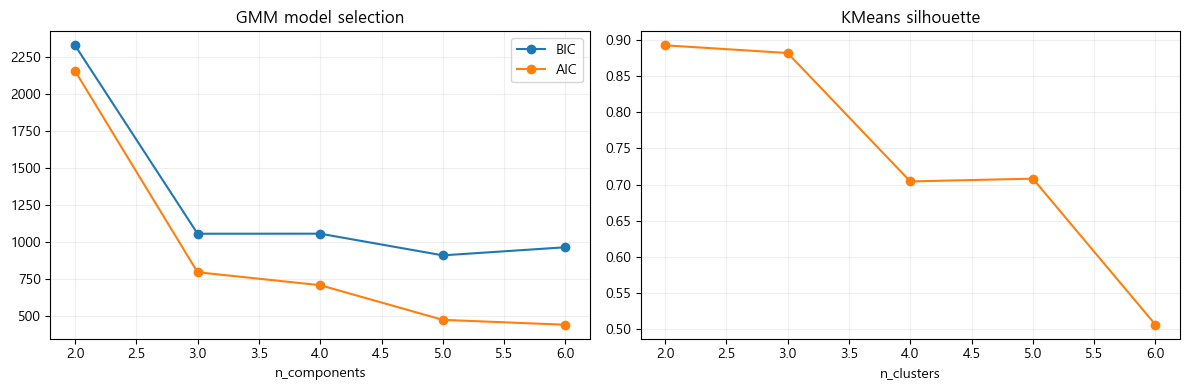

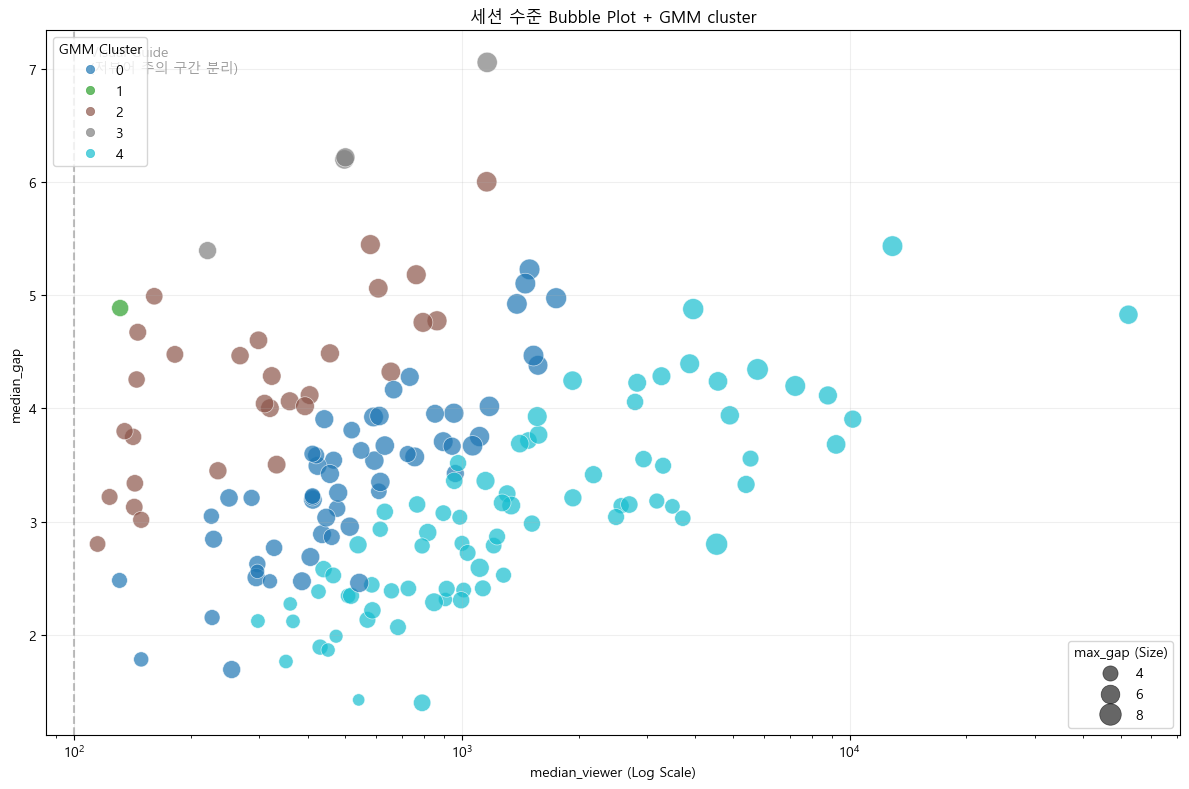

In [ ]:
# proposal의 clustering 단계 수행
# session_summary_10m를 기반으로 정상 세션 유형(normal behavioral types)을 먼저 나눈다
# GMM을 주력, KMeans를 비교군으로 사용한다

from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# clustering용 session table
cluster_data = session_summary_10m.copy()

# 제안서 논리상 '세션 행동 유형'을 나누는 변수들만 사용
# (max_gap 같은 극단적 이상치 지표는 배제하여 정상 방송의 스타일을 프로파일링)
cluster_data['log_median_viewer'] = np.log1p(cluster_data['median_viewer'])

cluster_features = [
    'log_median_viewer',
    'mean_chat',
    'mean_unique',
    'zero_chat_rate',
    'median_gap',
    'max_zero_run'
]

X = cluster_data[cluster_features].copy()
X_scaled = RobustScaler().fit_transform(X)

# 군집 수 탐색
k_values = list(range(2, min(7, len(cluster_data))))

gmm_bic = []
gmm_aic = []
km_sil = []

for k in k_values:
    # 500회 반복
    gmm = GaussianMixture(n_components=k, random_state=42, max_iter=500)
    gmm.fit(X_scaled)
    gmm_bic.append(gmm.bic(X_scaled))
    gmm_aic.append(gmm.aic(X_scaled))

    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_labels = km.fit_predict(X_scaled)
    km_sil.append(silhouette_score(X_scaled, km_labels))

# 최적 k 선택
best_gmm_k = k_values[int(np.argmin(gmm_bic))]
best_km_k = k_values[int(np.argmax(km_sil))]

print('GMM best k by BIC:', best_gmm_k)
print('KMeans best k by silhouette:', best_km_k)

# 최종 군집 적합
final_gmm = GaussianMixture(n_components=best_gmm_k, random_state=42, max_iter=500)
cluster_data['gmm_cluster'] = final_gmm.fit_predict(X_scaled)

final_km = KMeans(n_clusters=best_km_k, random_state=42, n_init=20)
cluster_data['kmeans_cluster'] = final_km.fit_predict(X_scaled)

# cluster profile table
gmm_profile = (
    cluster_data.groupby('gmm_cluster')
                .agg(
                    n_sessions=('run_id', 'size'),
                    median_viewer=('median_viewer', 'median'),
                    mean_chat=('mean_chat', 'mean'),
                    mean_unique=('mean_unique', 'mean'),
                    zero_chat_rate=('zero_chat_rate', 'mean'),
                    median_gap=('median_gap', 'median'),
                    max_zero_run=('max_zero_run', 'median')
                )
                .reset_index()
                .sort_values('median_viewer')
)

kmeans_profile = (
    cluster_data.groupby('kmeans_cluster')
                .agg(
                    n_sessions=('run_id', 'size'),
                    median_viewer=('median_viewer', 'median'),
                    mean_chat=('mean_chat', 'mean'),
                    mean_unique=('mean_unique', 'mean'),
                    zero_chat_rate=('zero_chat_rate', 'mean'),
                    median_gap=('median_gap', 'median'),
                    max_zero_run=('max_zero_run', 'median')
                )
                .reset_index()
                .sort_values('median_viewer')
)

print('\n--- GMM cluster profile ---')
display(gmm_profile.round(3))

print('\n--- KMeans cluster profile ---')
display(kmeans_profile.round(3))

# model selection diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, gmm_bic, marker='o', label='BIC')
axes[0].plot(k_values, gmm_aic, marker='o', label='AIC')
axes[0].set_title('GMM model selection')
axes[0].set_xlabel('n_components')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].plot(k_values, km_sil, marker='o', color='tab:orange')
axes[1].set_title('KMeans silhouette')
axes[1].set_xlabel('n_clusters')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 기존 bubble plot과 같은 좌표 위에 GMM cluster를 범례로 표시
fig, ax = plt.subplots(figsize=(12, 8))

# 산점도 렌더링
sc = ax.scatter(
    cluster_data['median_viewer'],
    cluster_data['median_gap'],
    s=cluster_data['max_gap'].fillna(0) * 30,
    c=cluster_data['gmm_cluster'],
    cmap='tab10',
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

ax.set_title('세션 수준 Bubble Plot + GMM cluster')
ax.set_xlabel('median_viewer (Log Scale)')
ax.set_ylabel('median_gap')
ax.set_xscale('log')
ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
ax.text(110, ax.get_ylim()[1] * 0.95, 'Visual Guide\n(저뷰어 주의 구간 분리)', color='gray', alpha=0.8)
ax.grid(True, alpha=0.2)

handles, labels = sc.legend_elements(prop="colors", alpha=0.7)
cluster_legend = ax.legend(handles, labels, loc="upper left", title="GMM Cluster")
ax.add_artist(cluster_legend)

handles_size, labels_size = sc.legend_elements(prop="sizes", alpha=0.6, num=4, func=lambda s: np.round(s / 30, 1))
ax.legend(handles_size, labels_size, loc="lower right", title="max_gap (Size)")

plt.tight_layout()
plt.show()

# 이후 섹터에서 쓰기 쉽게 덮어쓰기
session_summary_10m = cluster_data.copy()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Session-level Rule Screening (규칙 기반 1차 후보군 선별)</mark></b></span><br><br>

<b>[코드의 핵심 목적]</b><br>
앞선 시각화(Bubble Plot 등)에서 얻은 인사이트를 <b>데이터 기반의 명확한 규칙(Rule)</b>으로 수치화하여, 뷰봇 의심 세션을 1차적으로 걸러내는 작업이다.<br>
여기서 산출되는 <b>rule_score는 뷰봇이라는 것이 아니라, 사람이 먼저 확인해야 할 리뷰 우선순위(Review priority용 screening score)</b>를 의미한다.<br><br>

<b>[데이터 기반 임계값(Threshold) 설정 논리]</b><br>
• <b>1) viewer_floor (Q50):</b> 시청자 수 중앙값(하위 50%) 기준입니다. 시청자가 너무 적은 방송은 자연스럽게 채팅이 없을 수 있으므로, <b>일정 체급 이상의 방송만 분석 대상으로 삼기 위한 최소한의 안전장치(도메인 지식)</b>이다.<br>
• <b>2) zero_rate_cut (Q90):</b> 채팅이 아예 없는 비율이 <b>상위 10%에 달하는 극단적인 침묵</b> 세션을 잡아내는 기준선이다.<br>
• <b>3) gap 관련 변수 (IQR Fence):</b> 시청자와 채팅의 격차(median_gap, max_gap)를 평가할 때, 통계적인 이상치 탐지 기법인 <b>IQR 기반의 Fence</b>를 사용했다. 정상적인 데이터 분포를 크게 벗어난 <b>비정상적인 윗단의 격차를 수학적으로 컷팅</b>한다.<br><br>

<b>[의심 지수(Rule Score) 합산 및 후보군 도출]</b><br>
• <b>Flag 생성:</b> 위에서 정한 3가지 의심 기준(침묵, 격차, 최대 격차)을 넘을 때마다 1점씩(Flag) 부여한다.<br>
• <b>rule_score 계산:</b> 이 의심 시그널들을 모두 합산하여 <b>세션별 위험 척도(0~3점)</b>를 산출한다.<br>
• <b>최종 후보 선정:</b> <b>최소 체급을 넘기면서 동시에 의심 시그널이 2개 이상(rule_score >= 2)</b> 발생한 확실한 세션들만 엄선하여, 1차 뷰봇 의심 후보 리스트로 뽑아낸다.
</div>

In [ ]:
q_viewer = session_summary_10m['median_viewer'].quantile(0.50)
viewer_floor = q_viewer

# zero-chat rate는 상위 10% 수준의 극단적 silence 기준
zero_rate_cut = session_summary_10m['zero_chat_rate'].quantile(0.90)

# gap 관련 변수는 IQR 기반 fence 사용
gap_q25 = session_summary_10m['median_gap'].quantile(0.25)
gap_q75 = session_summary_10m['median_gap'].quantile(0.75)
gap_iqr = gap_q75 - gap_q25
gap_upper_fence = gap_q75 + 1.5 * gap_iqr

max_gap_q25 = session_summary_10m['max_gap'].quantile(0.25)
max_gap_q75 = session_summary_10m['max_gap'].quantile(0.75)
max_gap_iqr = max_gap_q75 - max_gap_q25
max_gap_upper_fence = max_gap_q75 + 1.5 * max_gap_iqr

# flag 생성
rule_screen = session_summary_10m.copy()

rule_screen['flag_viewer_floor'] = (rule_screen['median_viewer'] >= viewer_floor).astype(int)
rule_screen['flag_zero_high'] = (rule_screen['zero_chat_rate'] >= zero_rate_cut).astype(int)
rule_screen['flag_gap_high'] = (rule_screen['median_gap'] >= gap_upper_fence).astype(int)
rule_screen['flag_max_gap_high'] = (rule_screen['max_gap'] >= max_gap_upper_fence).astype(int)

# rule_score: suspicious flag만 합산
rule_screen['rule_score'] = (
    rule_screen['flag_zero_high']
    + rule_screen['flag_gap_high']
    + rule_screen['flag_max_gap_high']
)

# candidate: 일정 체급 이상 세션 중 suspicious signal 2개 이상
rule_screen['rule_candidate'] = (
    (rule_screen['flag_viewer_floor'] == 1) &
    (rule_screen['rule_score'] >= 2)
)

print('--- Rule Thresholds ---')
print(f'viewer floor (Q50): {viewer_floor:.1f}')
print(f'zero_chat_rate cut (Q90): {zero_rate_cut:.3f}')
print(f'median_gap upper fence: {gap_upper_fence:.3f}')
print(f'max_gap upper fence: {max_gap_upper_fence:.3f}\n')

print('--- Candidates Found ---')
print(f"Total Candidates: {rule_screen['rule_candidate'].sum()} sessions\n")

display(
    rule_screen[rule_screen['rule_candidate']]
    .sort_values(
        ['rule_score', 'zero_chat_rate', 'median_gap', 'max_gap'],
        ascending=[False, False, False, False]
    )
    [['user_id', 'run_id', 'median_viewer', 'zero_chat_rate',
      'median_gap', 'max_gap', 'rule_score']]
    .head(20)
)

--- Rule Thresholds ---
viewer floor (Q50): 633.0
zero_chat_rate cut (Q90): 0.162
median_gap upper fence: 5.906
max_gap upper fence: 8.245

--- Candidates Found ---
Total Candidates: 2 sessions



,user_id,run_id,median_viewer,zero_chat_rate,median_gap,max_gap,rule_score
61,4f0e2fbfad9960eee61770e144b820b3,44,1162.5,0.885965,7.055312,7.093405,2
123,b8263cd74372864eacb2d5bd16551882,40,1159.5,0.237288,6.001002,7.119636,2


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Session-level Isolation Forest</mark></b></span><br><br>

<b>[코드의 핵심 목적]</b><br>
앞서서 내가 만든 룰로 1차 검증을 했다면, 이번엔 <b>Isolation Forest algorithm</b>을 통해 데이터 스스로 정상 범주에서 벗어난 anomaly를 찾아내도록 한다.<br>
이 결과 역시 최종 판정이 아니라, <b>후속 검토를 위한 Anomaly Ranking을 제공</b>하는 것이 주 목적이다.<br><br>

<b>[Isolation Forest 변수 선정 및 스케일링]</b><br>
• 변수 중복을 최소화하면서도, 뷰봇 판별의 핵심인 <b>(max_zero_run, zero_chat_rate)</b>과 <b>(median_gap, max_gap)</b> 변수는 반드시 포함해 모델을 훈련시킨다.<br><br>

<b>[이상 점수(Anomaly Score) 산출 논리]</b><br>
• 각 세션이 얼마나 고립되기 쉬운지를 점수로 매깁니다. <b>점수가 높을수록 Anomaly</b>를 의미하며, -1 라벨이 부여됩니다.<br>
• 하단의 <b>Histogram 시각화</b>를 통해 전체 세션 중 어느 정도의 비율이 'Score=0 (Default Threshold)' 선을 넘어 비정상으로 분류되었는지 직관적으로 확인한다.<br><br>

<b>[강력한 2중 교차 검증]</b><br>
이 분석의 가장 핵심적인 부분이다. 앞서 만든 <b>규칙 기반 결과</b>와 방금 도출한 <b>iforest_label</b>를 병합하여 교차표를 만든다.<br>
• <b>내 직관과 iForest가 공통으로 지목한 세션</b>을 추출한다.<br>
• 두 가지 전혀 다른 접근 방식이 모두 이상하다고 판단한 세션이므로, <b>실제 뷰봇일 확률이 극도로 높은 최상위 검토 대상</b>이 된다.
</div>

IsolationForest anomaly 개수: 19
Rule-based vs IsolationForest 교차표


iforest_label,-1,1
rule_candidate,,
False,17,151
True,2,0


Rule과 iForest가 공통으로 지목한 세션 수: 2


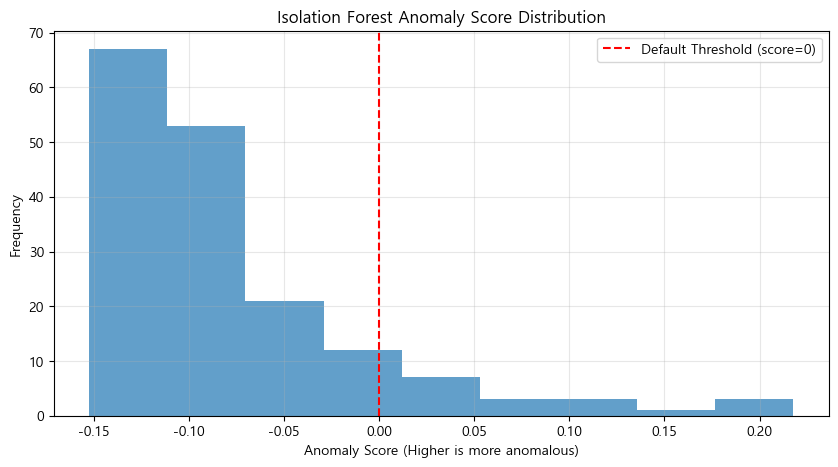

,user_id,run_id,n,start_ts,end_ts,median_viewer,max_viewer,mean_chat,mean_unique,zero_chat_rate,max_zero_run,median_gap,max_gap,log_median_viewer,gmm_cluster,kmeans_cluster,iforest_label,iforest_score,rule_candidate,rule_score
20,123cf2a78842d677e66ec57f3e3039c2,37,116,2026-04-16 17:00:00,2026-04-16 19:00:00,131.5,150.0,0.051724,0.025862,0.974138,63,4.886234,5.017280,4.886583,1,1,-1,0.217842,False,1
9,0b33823ac81de48d5b78a38cdbc0ab94,41,121,2026-04-17 20:00:00,2026-04-17 22:00:00,52368.0,64772.0,412.950413,262.413223,0.000000,0,4.827724,6.310466,10.866070,4,0,-1,0.190814,False,0
61,4f0e2fbfad9960eee61770e144b820b3,44,114,2026-04-18 20:00:00,2026-04-18 21:59:00,1162.5,1203.0,0.254386,0.140351,0.885965,26,7.055312,7.093405,7.059188,3,1,-1,0.181069,True,2
115,b044e3a3b9259246bc92e863e7d3f3b8,42,61,2026-04-17 23:00:00,2026-04-18 00:00:00,4541.0,5055.0,325.032787,125.590164,0.016393,1,2.801675,8.315811,8.421123,4,0,-1,0.161839,False,1
155,df434464f7e4802bee47c4b9c88331f7,40,119,2026-04-17 17:00:00,2026-04-17 18:59:00,498.0,602.0,0.151261,0.151261,0.865546,28,6.198479,6.396930,6.212606,3,1,-1,0.124088,False,2
156,df434464f7e4802bee47c4b9c88331f7,43,120,2026-04-18 17:00:00,2026-04-18 19:00:00,501.0,518.0,0.391667,0.200000,0.825000,20,6.216606,6.251904,6.218600,3,1,-1,0.118817,False,2
84,7de18e974bc4bbbe6737d941b72aa2f8,31,119,2026-04-14 17:00:00,2026-04-14 19:00:00,221.0,258.0,0.210084,0.109244,0.890756,9,5.393628,5.556828,5.402677,3,1,-1,0.107383,False,1
159,ed0ef5729a1cce903c72638cd8062512,43,120,2026-04-18 17:00:00,2026-04-18 18:59:00,161.0,177.0,1.500000,1.050000,0.533333,14,4.990433,5.176150,5.087596,2,1,-1,0.071960,False,1
28,17d8605fc37fb5ef49f5f67ae786fe4e,45,15,2026-04-18 23:00:00,2026-04-18 23:14:00,542.0,550.0,150.533333,56.066667,0.000000,0,1.427116,2.613740,6.297109,4,0,-1,0.065694,False,0
8,0b33823ac81de48d5b78a38cdbc0ab94,38,121,2026-04-16 20:00:00,2026-04-16 22:00:00,5789.0,25407.0,124.619835,73.223140,0.008264,1,4.344510,7.948738,8.663888,4,0,-1,0.060646,False,0


,user_id,run_id,n,start_ts,end_ts,median_viewer,max_viewer,mean_chat,mean_unique,zero_chat_rate,max_zero_run,median_gap,max_gap,log_median_viewer,gmm_cluster,kmeans_cluster,iforest_label,iforest_score,rule_candidate,rule_score
61,4f0e2fbfad9960eee61770e144b820b3,44,114,2026-04-18 20:00:00,2026-04-18 21:59:00,1162.5,1203.0,0.254386,0.140351,0.885965,26,7.055312,7.093405,7.059188,3,1,-1,0.181069,True,2
121,b8263cd74372864eacb2d5bd16551882,40,118,2026-04-17 17:00:00,2026-04-17 18:59:00,1159.5,1253.0,2.762712,2.144068,0.237288,3,6.001002,7.119636,7.056606,2,0,-1,0.044663,True,2


In [ ]:
# proposal의 anomaly 단계로 넘어가기 위한 비지도 이상치 라벨
# session_summary_10m 기준 세션 수준 screening
# 최종 판정이 아니라 후속 검토용 anomaly ranking

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

iforest_data = session_summary_10m.copy()
iforest_data['log_median_viewer'] = np.log1p(iforest_data['median_viewer'])

# feature redundancy를 줄이되,
# proposal에서 중요하게 보는 unique/zero persistence/gap은 남김
session_features = [
    'log_median_viewer',
    'zero_chat_rate',
    'median_gap',
    'max_gap',
    'mean_unique',
    'max_zero_run'
]

X = iforest_data[session_features].copy()
X_scaled = RobustScaler().fit_transform(X)

iso = IsolationForest(
    random_state=42,
    contamination='auto'
)

iforest_data['iforest_label'] = iso.fit_predict(X_scaled)
iforest_data['iforest_score'] = -iso.decision_function(X_scaled)

print('IsolationForest anomaly 개수:', (iforest_data['iforest_label'] == -1).sum())

# Rule-based screening 결과와 안전하게 merge
iforest_data = iforest_data.merge(
    rule_screen[['user_id', 'run_id', 'rule_candidate', 'rule_score']],
    on=['user_id', 'run_id'],
    how='left'
)

# Cross-check: Rule vs iForest
cross_tab = pd.crosstab(
    iforest_data['rule_candidate'],
    iforest_data['iforest_label'],
    rownames=['rule_candidate'],
    colnames=['iforest_label']
)

print('Rule-based vs IsolationForest 교차표')
display(cross_tab)

both_anomaly = iforest_data[
    (iforest_data['iforest_label'] == -1) &
    (iforest_data['rule_candidate'] == True)
].copy()

print('Rule과 iForest가 공통으로 지목한 세션 수:', len(both_anomaly))

# Score 분포 확인
plt.figure(figsize=(10, 5))
plt.hist(iforest_data['iforest_score'], bins='sturges', color='tab:blue', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Default Threshold (score=0)')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Anomaly Score (Higher is more anomalous)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 이상 점수 상위 세션
print(
    iforest_data.sort_values('iforest_score', ascending=False)
                .head(20)
)

# Rule + iForest 공통 상위 세션
print(
    both_anomaly.sort_values(
        ['rule_score', 'iforest_score', 'median_gap', 'max_gap'],
        ascending=[False, False, False, False]
    ).head(20)
)

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Bubble Plot에 Isolation Forest 결과 시각화 병합</mark></b></span><br><br>

<b>[코드의 핵심 목적]</b><br>
기존에 확립해둔 강력한 <b>Bubble Plot의 직관성을 그대로 유지</b>하면서, 그 위에 iForest가 찾아낸 <b>이상치 라벨만 직관적으로 덧입혀 강조</b>하는 작업이다. 이를 통해 모델의 판별 결과가 실제 데이터 분포 상에서 타당한지 눈으로 직접 검증할 수 있다.<br><br>

<b>[시각화 논리]</b><br>
단순히 점을 찍는 것을 넘어, 시각적 대비를 극대화하기 위해 정상 세션과 이상 세션의 <b>렌더링 방식을 의도적으로 분리</b>했다.<br>
• <b>정상 세션(Normal):</b> 투명도를 극단적으로 낮추고, 테두리를 없애 배경의 <b>옅은 흐름</b>으로만 남겨둔다.<br>
• <b>이상 세션(Anomaly):</b> 투명도를 높이고, <b>붉은색 테두리</b>를 둘러 정상 데이터들 사이에서 뷰봇 의심군이 확연하게 튀어나와 보이도록 처리했다.<br>
• <b>스케일 동기화:</b> 두 집단을 따로 그리더라도 색상 범례가 왜곡되지 않도록 컬러맵의 스케일을 고정시켰다.<br><br>

<b>[추가 가이드 및 주석]</b><br>
• <b>가이드라인:</b> 이전과 마찬가지로 X축 100명 선에 가이드라인을 그어, 시청자가 적어 자연스럽게 채팅이 없는 방송 구간을 시각적으로 분리해준다.<br>
• <b>최상위 이상치 특정:</b> isolation_score로 <b>가장 비정상적이라고 판단한 3개의 세션</b>을 추출하여 그래프 위에 붉은색 굵은 글씨로 표기했다. 이 3개는 최우선적으로 상세 데이터 리뷰가 필요한 세션임을 의미한다.
</div>

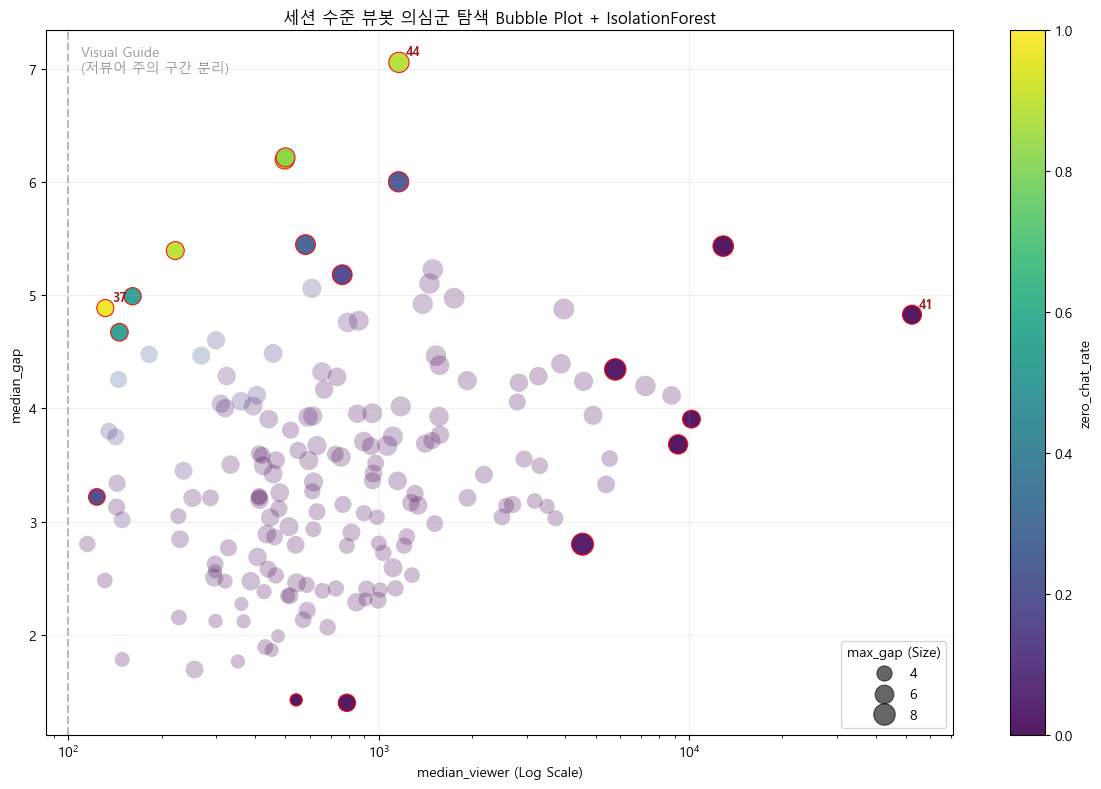

In [ ]:
bubble_data = iforest_data.copy()

fig, ax = plt.subplots(figsize=(12, 8))

normal = bubble_data[bubble_data['iforest_label'] == 1]
anomaly = bubble_data[bubble_data['iforest_label'] == -1]

# 컬러맵 동기화를 위한 전역 최소/최대값 설정 (비율이므로 0~1 고정)
c_min, c_max = 0.0, 1.0

# 정상 세션은 옅게
ax.scatter(
    normal['median_viewer'],
    normal['median_gap'],
    s=normal['max_gap'].fillna(0) * 30,
    c=normal['zero_chat_rate'].fillna(0),
    cmap='viridis',
    vmin=c_min, vmax=c_max,
    alpha=0.25,
    edgecolor='none'
)

# 이상 세션만 강조
sc = ax.scatter(
    anomaly['median_viewer'],
    anomaly['median_gap'],
    s=anomaly['max_gap'].fillna(0) * 30,
    c=anomaly['zero_chat_rate'].fillna(0),
    cmap='viridis',
    vmin=c_min, vmax=c_max,
    alpha=0.9,
    edgecolor='red',
    linewidth=0.8
)

ax.set_title('세션 수준 뷰봇 의심군 탐색 Bubble Plot + IsolationForest')
ax.set_xlabel('median_viewer (Log Scale)')
ax.set_ylabel('median_gap')
ax.set_xscale('log')
ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
ax.text(110, ax.get_ylim()[1] * 0.95, 'Visual Guide\n(저뷰어 주의 구간 분리)', color='gray', alpha=0.8)
ax.grid(True, alpha=0.2)

# 색상 범례
plt.colorbar(sc, ax=ax, label='zero_chat_rate')

# 버블 크기 범례 추가
handles, labels = sc.legend_elements(prop="sizes", alpha=0.6, num=4, func=lambda s: np.round(s / 30, 1))
ax.legend(handles, labels, loc="lower right", title="max_gap (Size)")

# 최상위 이상치 주석 추가 (Score 기준 상위 3개)
top_anomalies = anomaly.sort_values('iforest_score', ascending=False).head(3)
for _, row in top_anomalies.iterrows():
    ax.annotate(
        f"{row['run_id']}",
        (row['median_viewer'], row['median_gap']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='darkred',
        alpha=0.9
    )

plt.tight_layout()
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Minute-level Candidate Flags (분 단위 뷰봇 의심 순간 추출)</mark></b></span><br><br>

<b>[코드의 핵심 목적]</b><br>
최종적인 이상치 점수를 매기기 전에, EDA를 위해 <b>'정확히 몇 분에 비정상적인 패턴이 발생했는가?'</b>를 투명한 데이터 기반 규칙으로 찾아내어 해당 분에 라벨을 찍는 과정입니다.<br><br>

<b>[통계적 기준 설정의 섬세함 (상대평가 + 절대평가)]</b><br>
이 코드의 특징은 방송마다 체급이 다르다는 것을 통계적으로 완벽히 통제했다는 것이다.<br>
• <b>세션별 IQR Fence (상대평가):</b> 대기업 방송의 100명 증가와 하꼬방의 100명 증가는 의미가 다르다. 따라서 <b>각 세션별로 독립적인 IQR을 계산</b>하여, 해당 방송의 평소 흐름을 벗어나는 '상대적 급증' 기준을 세웠다.<br>
• <b>Spike Floor (절대평가):</b> 시청자 적은 방에서 1명 보다가 3명 보는 것을 급증이라고 착각하지 않도록, 일정 체급 이상 방송들의 실제 시청자 증가량 중앙값을 계산해 <b>최소한 이 정도는 넘어야 급증으로 인정하는 절대적 하한선</b>을 만들었다.<br><br>

<b>[2가지 핵심 뷰봇 의심 패턴 (논리적 시나리오)]</b><br>
위의 기준들을 바탕으로, 뷰봇이 투입될 때 나타나는 전형적인 엇박자 현상을 조건식으로 구현했다.<br>
• <b>1. 급증 불일치 (candidate_spike_mismatch):</b> 시청자 수는 상한선을 뚫고 급증했는데, <b>정작 채팅량이나 채팅 치는 고유 유저 수는 전혀 늘지 않거나 오히려 감소(<= 0)하는 기형적인 순간</b>을 포착한다. (뷰봇 투입 순간 포착)<br>
• <b>2. 비정상적 격차 유지 (candidate_sustained_gap):</b> 시청자 규모도 일정 이상 통과했고, 시청자-채팅 간의 격차가 해당 방송의 정상 범위를 훌쩍 넘었는데, <b>채팅창은 완전히 얼어붙어 있는(0이거나 감소하는) 상태가 지속되는 순간</b>을 포착한다. (뷰봇 유지 구간 포착)<br><br>

<b>[결론 및 병합]</b><br>
이 두 가지 조건 중 하나라도 만족하는 1분 단위의 구간을 <b>`candidate_minute`</b>로 최종 확정(True) 짓고, 이를 메인 데이터프레임에 병합하여 <b>이후 시계열 그래프에서 이 의심 순간들에만 빨간 점을 찍어 시각화</b>할 수 있도록 밑그림을 완성했다.
</div>

In [ ]:
# 최종 anomaly score가 아니라 EDA용 후보 minute를 투명한 규칙으로 추출
# proposal의 viewer spike + weak chat response + unchanged unique chatters 논리 반영
# 세션별 IQR fence + 세션 체급 gate + 데이터 기반 spike floor 사용

session_fences = (
    plot_df.groupby(['user_id', 'run_id'])
           .agg(
               n=('minute_ts', 'size'),
               gap_q25=('viewer_chat_log_gap', lambda s: s.quantile(0.25)),
               gap_q75=('viewer_chat_log_gap', lambda s: s.quantile(0.75)),
               dv_q25=('delta_viewer_1m', lambda s: s.quantile(0.25)),
               dv_q75=('delta_viewer_1m', lambda s: s.quantile(0.75))
           )
           .reset_index()
)

session_fences['gap_iqr'] = session_fences['gap_q75'] - session_fences['gap_q25']
session_fences['dv_iqr'] = session_fences['dv_q75'] - session_fences['dv_q25']

session_fences['gap_upper_fence'] = session_fences['gap_q75'] + 1.5 * session_fences['gap_iqr']
session_fences['dv_upper_fence'] = session_fences['dv_q75'] + 1.5 * session_fences['dv_iqr']

minute_flags = (
    plot_df.merge(
        session_fences[['user_id', 'run_id', 'n', 'gap_upper_fence', 'dv_upper_fence']],
        on=['user_id', 'run_id'],
        how='left'
    )
    .merge(
        rule_screen[['user_id', 'run_id', 'flag_viewer_floor']],
        on=['user_id', 'run_id'],
        how='left'
    )
)

minute_flags = minute_flags[minute_flags['n'] >= 10].copy()

# 첫 minute NaN 방어
minute_flags['delta_viewer_1m'] = minute_flags['delta_viewer_1m'].fillna(0)
minute_flags['delta_chat_1m'] = minute_flags['delta_chat_1m'].fillna(0)
minute_flags['unique_delta_1m'] = minute_flags['unique_delta_1m'].fillna(0)

# 세션 체급을 통과한 방송들만 대상으로 "유의미한 viewer spike"의 데이터 기반 floor 설정
positive_dv = minute_flags.loc[
    (minute_flags['flag_viewer_floor'] == 1) &
    (minute_flags['delta_viewer_1m'] > 0),
    'delta_viewer_1m'
]

spike_floor = positive_dv.quantile(0.50)

minute_flags['flag_gap_high'] = (
    minute_flags['viewer_chat_log_gap'] > minute_flags['gap_upper_fence']
)

minute_flags['flag_viewer_spike'] = (
    (minute_flags['flag_viewer_floor'] == 1) &
    (minute_flags['delta_viewer_1m'] > minute_flags['dv_upper_fence']) &
    (minute_flags['delta_viewer_1m'] >= spike_floor)
)

# strict rule: EDA 단계에서는 <= 0 유지
minute_flags['flag_chat_nonresponse'] = minute_flags['delta_chat_1m'] <= 0
minute_flags['flag_unique_stagnant'] = minute_flags['unique_delta_1m'] <= 0
minute_flags['flag_zero_chat'] = minute_flags['zero_chat']

minute_flags['candidate_spike_mismatch'] = (
    minute_flags['flag_viewer_spike'] &
    (minute_flags['flag_chat_nonresponse'] | minute_flags['flag_unique_stagnant'])
)

minute_flags['candidate_sustained_gap'] = (
    (minute_flags['flag_viewer_floor'] == 1) &
    minute_flags['flag_gap_high'] &
    (minute_flags['flag_zero_chat'] | minute_flags['flag_chat_nonresponse'])
)

minute_flags['candidate_minute'] = (
    minute_flags['candidate_spike_mismatch'] |
    minute_flags['candidate_sustained_gap']
)

print('spike floor (viewer-floor 통과 세션의 positive delta Q50):', round(spike_floor, 3))
print('candidate minute 수:', int(minute_flags['candidate_minute'].sum()))

candidate_minutes = (
    minute_flags.loc[
        minute_flags['candidate_minute'],
        ['user_id', 'run_id', 'minute_ts',
         'viewer_count_last', 'chat_count', 'unique_chatters',
         'delta_viewer_1m', 'delta_chat_1m', 'unique_delta_1m',
         'viewer_chat_log_gap',
         'candidate_spike_mismatch', 'candidate_sustained_gap']
    ]
    .sort_values(['user_id', 'run_id', 'minute_ts'])
)

display(candidate_minutes.head(20))

plot_df = plot_df.merge(
    minute_flags[['user_id', 'run_id', 'minute_ts', 'candidate_minute']],
    on=['user_id', 'run_id', 'minute_ts'],
    how='left'
)
plot_df['candidate_minute'] = plot_df['candidate_minute'].fillna(False)

spike floor (viewer-floor 통과 세션의 positive delta Q50): 14.0
candidate minute 수: 367


,user_id,run_id,minute_ts,viewer_count_last,chat_count,unique_chatters,delta_viewer_1m,delta_chat_1m,unique_delta_1m,viewer_chat_log_gap,candidate_spike_mismatch,candidate_sustained_gap
338,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:14:00,879.0,40,12,41.0,-12.0,-18.0,3.066350,True,False
340,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:16:00,983.0,33,9,104.0,3.0,-1.0,3.365265,True,False
346,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:22:00,1048.0,38,12,89.0,0.0,2.0,3.292031,True,False
347,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:23:00,1048.0,10,10,0.0,-28.0,-2.0,4.557697,False,True
352,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:28:00,1052.0,6,6,20.0,-27.0,-10.0,5.013488,False,True
360,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:36:00,1051.0,19,13,47.0,-25.0,2.0,3.962716,True,False
372,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:48:00,1223.0,60,18,88.0,-32.0,-11.0,2.999006,True,False
373,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 20:49:00,1292.0,34,18,69.0,-26.0,0.0,3.609372,True,False
440,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 21:56:00,991.0,35,23,60.0,-3.0,4.0,3.316204,True,False
442,083c66a5cfce51967bcad5c1b0b86e5d,35,2026-04-15 21:58:00,984.0,3,3,0.0,-17.0,-10.0,5.506347,False,True


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Minute-level Candidate Intervals (연속된 의심 구간 병합 및 요약)</mark></b></span><br><br>

<b>[코드의 핵심 목적]</b><br>
뷰봇은 보통 1분만 들어왔다 빠지는 것이 아니라 <b>일정 시간 동안 지속적으로 투입</b>된다. 따라서 낱개의 1분짜리 의심 기록들을 이어 붙여서, <b>"언제부터 언제까지 몇 분 동안 공격이 지속되었는가?"</b>를 하나의 '사건' 단위로 요약하는 것이 목적이다.<br><br>

<b>[1분짜리 단절(노이즈) 허용 논리 - 킬링 포인트]</b><br>
데이터 수집 과정의 네트워크 지연이나 일시적인 변동으로 인해, 의심 구간 중간에 딱 1분 정도 조건에 미달하는 순간이 생길 수 있다. (예: 10분, 11분, <b>(12분 누락)</b>, 13분, 14분)<br>
• `gt(pd.Timedelta(minutes=2))`: 두 기록 사이의 시간 차이가 2분을 초과할 때만 new_interval로 끊는다. 즉, <b>중간에 딱 1분이 빠진 정도는 노이즈로 간주하고 하나의 연속된 뷰봇 투입 구간으로 부드럽게 이어 붙여준다.</b><br><br>

<b>[구간 요약 및 심각도 산출]</b><br>
이어 붙인 하나의 사건에 대해 다각도의 요약 지표를 뽑아냅니다.<br>
• <b>duration_minutes:</b> 처음 시작부터 끝날 때까지의 총 경과 시간<br>
• <b>flagged_minutes:</b> 그 기간 중 <b>실제로 의심 조건에 적발된 순수 시간</b><br>
• <b>bridge_minutes / flag_density:</b> 중간에 허용해 준 1분짜리 단절이 몇 번 있었는지, 전체 기간 대비 순수 의심 시간의 <b>밀도</b>가 얼마나 빽빽한지를 계산한다. 밀도가 1.0에 가까울수록 빼도 박도 못하는 지속적 뷰봇 투입을 의미한다.<br><br>

<b>[최우선 검토 대상 정렬 (우선순위 부여)]</b><br>
이후 사람이 직접 데이터를 리뷰할 때 무엇부터 봐야 할지 명확한 기준을 세웠다.<br>
1. <b>flagged_minutes (순수 의심 분 수):</b> 가장 오랫동안 의심 패턴이 지속된 징후를 1순위로 본다.<br>
2. <b>flag_density (밀도):</b> 단절 없이 빽빽하게 뷰봇 패턴이 유지된 것을 2순위로 본다.<br>
3. <b>max_gap / max_viewer:</b> 시청자와 채팅의 격차가 크고, 시청자 규모 자체가 컸던 방송을 그 다음으로 본다.
</div>

In [ ]:
candidate_minutes = candidate_minutes.sort_values(
    ['user_id', 'run_id', 'minute_ts']
).copy()

# 1분짜리 단절 1개 허용
candidate_minutes['new_interval'] = (
    candidate_minutes.groupby(['user_id', 'run_id'])['minute_ts']
                     .diff()
                     .gt(pd.Timedelta(minutes=2))
                     .fillna(True)
)

candidate_minutes['interval_id'] = (
    candidate_minutes.groupby(['user_id', 'run_id'])['new_interval']
                     .cumsum()
)

candidate_intervals = (
    candidate_minutes.groupby(['user_id', 'run_id', 'interval_id'])
                     .agg(
                         start_ts=('minute_ts', 'min'),
                         end_ts=('minute_ts', 'max'),
                         flagged_minutes=('minute_ts', 'size'),
                         max_viewer=('viewer_count_last', 'max'),
                         mean_chat_flagged=('chat_count', 'mean'),
                         mean_unique_flagged=('unique_chatters', 'mean'),
                         max_gap=('viewer_chat_log_gap', 'max'),
                         zero_chat_share_flagged=('chat_count', lambda s: (s == 0).mean()),
                         spike_mismatch_minutes=('candidate_spike_mismatch', 'sum'),
                         sustained_gap_minutes=('candidate_sustained_gap', 'sum')
                     )
                     .reset_index()
)

candidate_intervals['duration_minutes'] = (
    ((candidate_intervals['end_ts'] - candidate_intervals['start_ts']).dt.total_seconds() / 60) + 1
).astype(int)

candidate_intervals['bridge_minutes'] = (
    candidate_intervals['duration_minutes'] - candidate_intervals['flagged_minutes']
)

candidate_intervals['flag_density'] = (
    candidate_intervals['flagged_minutes'] / candidate_intervals['duration_minutes']
)

# 실제 suspicious 분 수를 가장 우선
candidate_intervals = candidate_intervals.sort_values(
    ['flagged_minutes', 'flag_density', 'max_gap', 'max_viewer'],
    ascending=[False, False, False, False]
)

print(candidate_intervals.head(20))

,user_id,run_id,interval_id,start_ts,end_ts,flagged_minutes,max_viewer,mean_chat_flagged,mean_unique_flagged,max_gap,zero_chat_share_flagged,spike_mismatch_minutes,sustained_gap_minutes,duration_minutes,bridge_minutes,flag_density
296,dae2de8eaa005a59163f2e4c045e1aa1,32,4,2026-04-14 21:43:00,2026-04-14 21:47:00,4,1541.0,145.750000,66.250000,2.725715,0.000000,4,0,5,1,0.800000
26,0e604eba7206f04b1e5f15e0a1cb2616,36,2,2026-04-15 23:40:00,2026-04-15 23:45:00,4,683.0,0.000000,0.000000,6.527958,1.000000,0,4,6,2,0.666667
14,0b33823ac81de48d5b78a38cdbc0ab94,38,1,2026-04-16 20:09:00,2026-04-16 20:12:00,3,21253.0,125.666667,93.000000,5.485187,0.000000,3,0,4,1,0.750000
113,554e99695decc451d57788b1fd5d5c07,44,2,2026-04-18 20:45:00,2026-04-18 20:49:00,3,938.0,1.333333,1.333333,6.822197,0.333333,0,3,5,2,0.600000
65,26ae7850ad5b6b09ca864d482dc7fa50,48,1,2026-04-19 23:46:00,2026-04-19 23:50:00,3,4541.0,7.666667,7.000000,6.453850,0.000000,0,3,5,2,0.600000
16,0b33823ac81de48d5b78a38cdbc0ab94,38,3,2026-04-16 20:20:00,2026-04-16 20:24:00,3,23745.0,202.333333,128.333333,5.012002,0.000000,3,0,5,2,0.600000
289,d2fb83a5db130bf4d273c981b82ca41f,46,7,2026-04-19 18:42:00,2026-04-19 18:43:00,2,1320.0,2.500000,2.500000,6.087532,0.000000,2,0,2,0,1.000000
220,aed9d6557bebfb21ab3d081b862cdd2d,42,1,2026-04-18 00:01:00,2026-04-18 00:02:00,2,1588.0,10.500000,7.500000,5.173636,0.000000,2,0,2,0,1.000000
13,0b33823ac81de48d5b78a38cdbc0ab94,38,0,2026-04-16 20:04:00,2026-04-16 20:05:00,2,18590.0,296.500000,185.500000,4.846826,0.000000,2,0,2,0,1.000000
1,083c66a5cfce51967bcad5c1b0b86e5d,35,1,2026-04-15 20:22:00,2026-04-15 20:23:00,2,1048.0,24.000000,11.000000,4.557697,0.000000,1,1,2,0,1.000000


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 최종 세션 패널 함수 (개별 세션 상세 시각화 대시보드)</mark></b></span><br><br>

<b>[코드의 핵심 목적]</b><br>
앞선 과정에서 뷰봇 의심군으로 걸러낸 특정 방송을 <b>1분 단위로 쪼개어 상세하게 진단</b>하기 위한 커스텀 시각화 함수다.<br>
데이터 전처리와 복잡한 계산은 밖에서 완료된 <b>plot_df</b>를 그대로 넘겨받아 사용함으로써, 이 함수는 <b>순수하게 데이터를 직관적으로 그려내는 역할에만 집중</b>하도록 깔끔하게 설계되었다.<br><br>

<b>[4단 패널 구성 논리]</b><br>
시간의 흐름(X축)을 완벽하게 공유(sharex=True)하는 4개의 그래프를 위아래로 배치하여, <b>특정 시점에 일어난 모든 지표의 변화를 한눈에 입체적으로 대조</b>할 수 있게 만든다.<br>
• <b>패널 1 (Viewer):</b> 시간에 따른 <b>전체 시청자 수의 흐름</b>을 파악한다.<br>
• <b>패널 2 (Chat / Unique):</b> <b>전체 채팅량과 고유 채팅 참여자 수</b>의 흐름을 겹쳐 그려, 방송의 실제 활성도 추이를 파악한다.<br>
• <b>패널 3 (Gap 추이):</b> 뷰봇 판별의 핵심 지표인 <b>시청자와 채팅 간의 격차</b>가 어떻게 변하는지 본다. 이 선이 위로 치솟을수록 시청자만 늘고 채팅은 없다는 기형적 상태를 의미한다.<br>
• <b>패널 4 (Delta 동기화 비교):</b> 하나의 차트 안에 <b>좌우 양쪽으로 축을 나누어</b> delta viewer과 delta chat을 직접 겹쳐서 비교한다. 시청자가 급증/급감할 때 채팅량도 정상적으로 따라가는지를 본다.<br><br>

<b>[시각적 하이라이트 및 주의 구간 강조]</b><br>
단순히 선 그래프만 그리는 것에 그치지 않고, <b>axvspan</b> 함수를 활용해 분석가의 시선이 꽂혀야 할 <b>특정 분의 배경에 색을 칠해주는 기능</b>이 포함되어 있다.<br>
• <b><span style="color: #e53e3e;">옅은 붉은색 배경 (Zero Times):</span></b> 채팅이 완전히 멈춰버린(0 chat) 침묵의 구간들을 칠해준다.<br>
• <b><span style="color: #d97706;">주황색 배경 (Candidate Times):</span></b> 섹터 15에서 정교한 규칙으로 찾아낸 <b>'시청자 급증 불일치' 또는 '비정상적 격차 유지'가 발생한 진짜 뷰봇 의심 순간</b>을 더 진하게 칠해줍니다. 최종 리뷰어는 이 색칠된 구간만 집중적으로 파헤치면 된다.
</div>

In [ ]:
def plot_session_panel(plot_df, user_id, run_id):
    g = plot_df[(plot_df['user_id'] == user_id) & (plot_df['run_id'] == run_id)].copy()
    g = g.sort_values('minute_ts')

    fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

    c_view = 'tab:blue'
    c_chat = 'tab:orange'
    c_uniq = 'tab:green'
    c_gap = 'tab:purple'

    axes[0].plot(g['minute_ts'], g['viewer_count_last'], color=c_view, linewidth=1.5)
    axes[0].set_title(f'Session overview: user_id={user_id}, run_id={run_id}')
    axes[0].set_ylabel('viewer', color=c_view)
    axes[0].set_ylim(bottom=0)

    axes[1].plot(g['minute_ts'], g['chat_count'], color=c_chat, linewidth=1.5, label='chat_count')
    axes[1].plot(g['minute_ts'], g['unique_chatters'], color=c_uniq, linewidth=1.5, label='unique_chatters')
    axes[1].set_ylabel('chat / unique')
    axes[1].set_ylim(bottom=0)
    axes[1].legend(loc='upper right')

    axes[2].plot(g['minute_ts'], g['viewer_chat_log_gap'], color=c_gap, linewidth=1.5)
    axes[2].set_ylabel('viewer-chat gap', color=c_gap)

    ax3_view = axes[3]
    ax3_chat = ax3_view.twinx()

    ax3_view.plot(g['minute_ts'], g['delta_viewer_1m'], color=c_view, alpha=0.8, label='delta viewer')
    ax3_chat.plot(g['minute_ts'], g['delta_chat_1m'], color=c_chat, alpha=0.8, label='delta chat')
    ax3_view.axhline(0, color='gray', linestyle='--', alpha=0.5)

    ax3_view.set_ylabel('delta viewer', color=c_view)
    ax3_chat.set_ylabel('delta chat', color=c_chat)
    ax3_view.tick_params(axis='y', colors=c_view)
    ax3_chat.tick_params(axis='y', colors=c_chat)
    ax3_view.set_xlabel('time')

    handles1, labels1 = ax3_view.get_legend_handles_labels()
    handles2, labels2 = ax3_chat.get_legend_handles_labels()
    ax3_view.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

    zero_times = g.loc[g['zero_chat'], 'minute_ts']
    candidate_times = g.loc[g['candidate_minute'], 'minute_ts']

    for ax in axes:
        for t in zero_times:
            ax.axvspan(t, t + pd.Timedelta(minutes=1), color='red', alpha=0.10, lw=0)
        for t in candidate_times:
            ax.axvspan(t, t + pd.Timedelta(minutes=1), color='orange', alpha=0.20, lw=0)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 클러스터 프로파일 정리 및 대표 의심 사례 선정</mark></b></span><br><br>

<b>[코드의 핵심 목적]</b><br>
지금까지 GMM, iForest과 규칙으로 찾아낸 결과들을 하나의 <b>Master Table</b>로 엮어낸다. <b>가장 설명하기 좋은 '대표 뷰봇 의심 사례'를 알고리즘이 자동으로 꼽아주도록 설계</b>되었다.<br><br>

<b>[1. 발표용 클러스터 프로파일링]</b><br>
• <b>np.select 로직:</b> 상위 33%라는 기준을 사용해, 각 군집에 <b>'고뷰어-고격차(high_viewer_high_gap)', '침묵방(silent_or_zero_chat)'</b> 같은 라벨(cluster_desc)을 자동으로 달아준다.<br><br>

<b>[2. 분석 지표의 총결산]</b><br>
• 방송의 기본 정보(session_summary), iforest_score, 연속된 뷰봇 공격 시간(total_flagged_minutes) 등 <b>서로 다른 섹터에서 만든 3가지 핵심 데이터프레임을 하나로 merge</b>한다.<br>
• 이를 통해 <b>"규칙 기반으로도 의심스럽고, 머신러닝으로도 점수가 높은"</b> 뷰봇 세션을 교차 검증해 찾아낼 수 있는 풀이 완성된다.<br><br>

<b>[3. 다각도 대표 세션(Top 1) 자동 추출 로직]</b><br>
단순히 하나만 뽑지 않고, <b>설명하려는 시나리오(관점)에 따라 각기 다른 1등</b>을 추출한다.<br>
• <b>(A) Rule 기반 1등:</b> 섹터 16의 논리를 이어받아, <b>'가장 오랫동안 의심 패턴이 지속된(total_flagged_minutes 최우선)'</b> 세션을 뽑는다.<br>
• <b>(B) iForest 기반 1등:</b> 머신러닝 알고리즘이 <b>수학적 데이터 분포상 가장 기형적이라고 판단한(iforest_score 최우선)</b> 세션을 뽑는다.<br>
• <b>(C) 군집별 1등:</b> 방송마다의 뷰봇 패턴은 다를 수 있으므로, <b>각 군집별로 가장 의심스러운 세션을 1개씩</b> 뽑아 대조군을 만든다.<br><br>

<b>[4. 상세 대시보드 자동 연결]</b><br>
• 위에서 뽑힌 <b>'가장 강력한 의심 세션'</b>의 ID를 변수로 저장한 뒤, 앞서 만든 <b>plot_session_panel 함수에 넣어</b> 1분 단위 상세 차트를 화면에 띄운다. 
</div>

대표 suspicious 세션(panel 기본값): 0b33823ac81de48d5b78a38cdbc0ab94 38


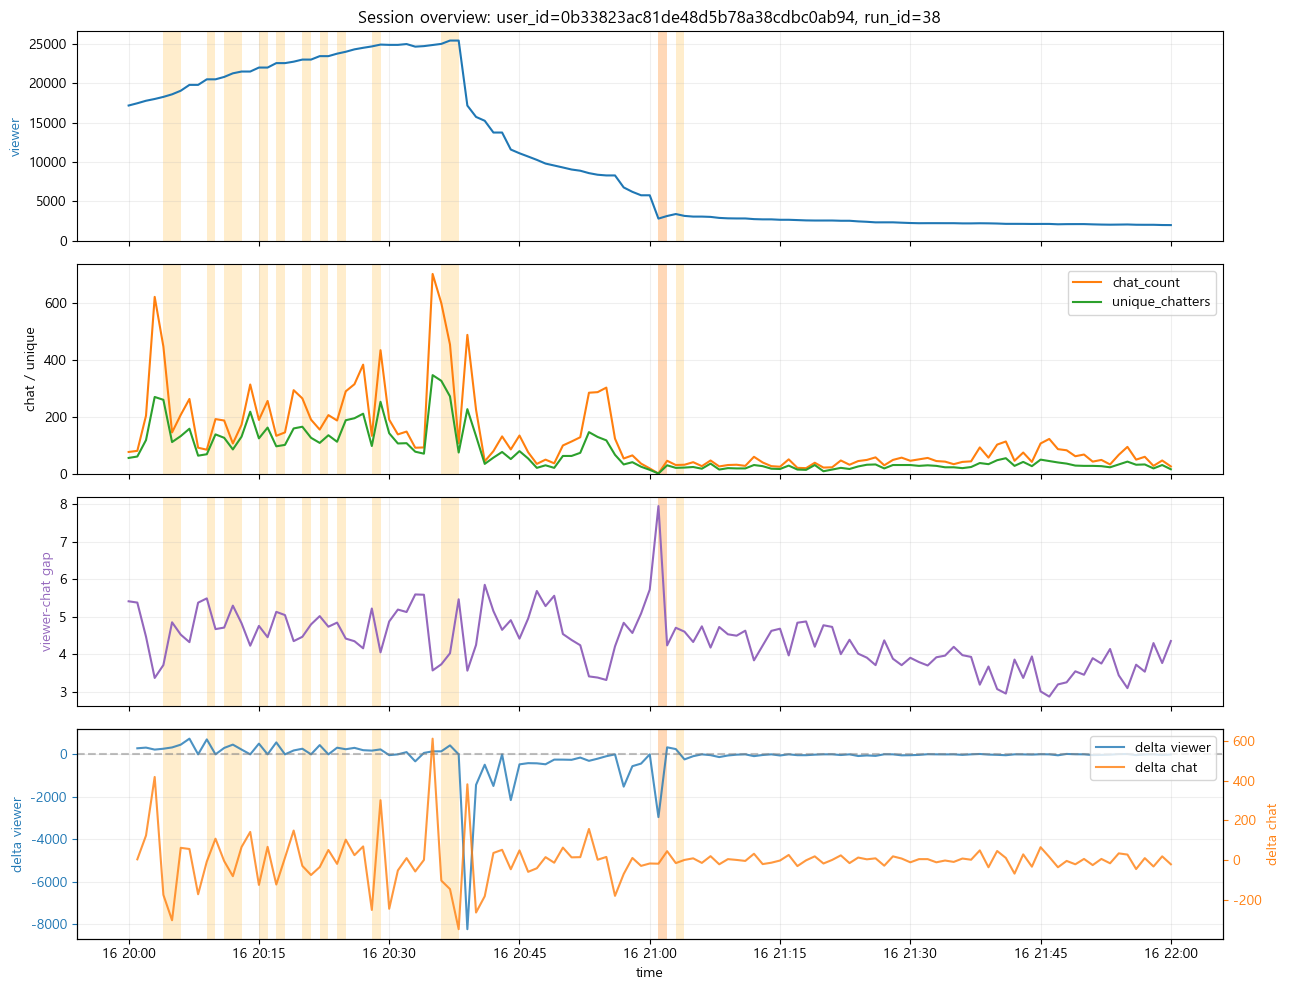

In [ ]:
cluster_profile_table = (
    cluster_data.groupby('gmm_cluster')
                .agg(
                    n_sessions=('run_id', 'size'),
                    median_viewer=('median_viewer', 'median'),
                    max_viewer=('max_viewer', 'median'),
                    mean_chat=('mean_chat', 'mean'),
                    mean_unique=('mean_unique', 'mean'),
                    zero_chat_rate=('zero_chat_rate', 'mean'),
                    median_gap=('median_gap', 'mean'),
                    max_zero_run=('max_zero_run', 'mean')
                )
                .reset_index()
                .sort_values('median_viewer')
                .reset_index(drop=True)
)

# 탐색용 자동 라벨
cluster_profile_table['cluster_desc'] = np.select(
    [
        (cluster_profile_table['median_viewer'] >= cluster_profile_table['median_viewer'].quantile(0.67)) &
        (cluster_profile_table['median_gap'] >= cluster_profile_table['median_gap'].quantile(0.67)),

        (cluster_profile_table['median_viewer'] >= cluster_profile_table['median_viewer'].quantile(0.67)) &
        (cluster_profile_table['median_gap'] < cluster_profile_table['median_gap'].quantile(0.67)),

        (cluster_profile_table['zero_chat_rate'] >= cluster_profile_table['zero_chat_rate'].quantile(0.67)) |
        (cluster_profile_table['max_zero_run'] >= cluster_profile_table['max_zero_run'].quantile(0.67))
    ],
    [
        'high_viewer_high_gap',
        'high_viewer_low_gap',
        'silent_or_zero_chat'
    ],
    default='mid_or_small_regular'
)


# 대표 세션 사례 선정용 session-level master table
interval_session_summary = (
    candidate_intervals.groupby(['user_id', 'run_id'])
                       .agg(
                           n_candidate_intervals=('interval_id', 'nunique'),
                           total_flagged_minutes=('flagged_minutes', 'sum'),
                           max_interval_duration=('duration_minutes', 'max'),
                           max_interval_flag_density=('flag_density', 'max'),
                           max_interval_gap=('max_gap', 'max')
                       )
                       .reset_index()
)

representative_pool = (
    session_summary_10m
    .merge(
        iforest_data[['user_id', 'run_id', 'iforest_score', 'iforest_label']],
        on=['user_id', 'run_id'],
        how='left'
    )
    .merge(
        interval_session_summary,
        on=['user_id', 'run_id'],
        how='left'
    )
)

fill_cols = [
    'n_candidate_intervals',
    'total_flagged_minutes',
    'max_interval_duration',
    'max_interval_flag_density',
    'max_interval_gap',
    'iforest_score'
]
representative_pool[fill_cols] = representative_pool[fill_cols].fillna(0)
representative_pool['iforest_label'] = representative_pool['iforest_label'].fillna(1)

# 대표 사례 선정

# 전체 suspicious 대표 1개: 섹터 16의 논리에 맞춰 total_flagged_minutes를 최우선 정렬 기준으로 사용
representative_suspicious_session = (
    representative_pool.sort_values(
        ['total_flagged_minutes', 'max_interval_duration', 'max_interval_gap', 'median_viewer'],
        ascending=[False, False, False, False]
    )
    .head(1)[['user_id', 'run_id', 'median_viewer', 'median_gap',
              'max_interval_duration', 'total_flagged_minutes',
              'max_interval_flag_density', 'iforest_score', 'gmm_cluster']]
    .reset_index(drop=True)
)

# Isolation Forest 기준 대표 이상치 1개: score를 우선, 그다음 flagged minute 수를 반영
representative_iforest_session = (
    representative_pool[representative_pool['iforest_label'] == -1]
    .sort_values(
        ['iforest_score', 'total_flagged_minutes', 'median_gap', 'median_viewer'],
        ascending=[False, False, False, False]
    )
    .head(1)[['user_id', 'run_id', 'median_viewer', 'median_gap',
              'iforest_score', 'max_interval_duration',
              'total_flagged_minutes', 'gmm_cluster']]
    .reset_index(drop=True)
)

# cluster별 대표 세션 1개씩: session_summary_10m 안에 이미 gmm_cluster가 있으므로 추가 merge 없이 바로 사용
representative_cluster_sessions = (
    representative_pool.sort_values(
        ['gmm_cluster', 'total_flagged_minutes', 'max_interval_duration', 'median_gap', 'median_viewer'],
        ascending=[True, False, False, False, False]
    )
    .groupby('gmm_cluster', as_index=False)
    .head(1)
    [['gmm_cluster', 'user_id', 'run_id', 'median_viewer', 'median_gap',
      'zero_chat_rate', 'max_interval_duration', 'total_flagged_minutes', 'iforest_score']]
    .sort_values('gmm_cluster')
    .reset_index(drop=True)
)

# 세션 패널 바로 호출하기 위한 scalar 변수
panel_user_id = representative_suspicious_session.loc[0, 'user_id']
panel_run_id = representative_suspicious_session.loc[0, 'run_id']

print('대표 suspicious 세션(panel 기본값):', panel_user_id, panel_run_id)
plot_session_panel(plot_df, panel_user_id, panel_run_id)

In [ ]:
#  EDA/Clustering 결과 엑셀 저장

save_tables = {
    'pearson_corr': pearson_corr,
    'spearman_corr': spearman_corr,
    'corr_focus': corr_focus,
    'session_summary': session_summary,
    'session_summary_10m': session_summary_10m,
    'rule_screen': rule_screen,
    'iforest_data': iforest_data,
    'candidate_minutes': candidate_minutes,
    'candidate_intervals': candidate_intervals,
    'gmm_profile': gmm_profile,
    'kmeans_profile': kmeans_profile,
    'representative_pool': representative_pool,
    'cluster_profile_table': cluster_profile_table
    
}

with pd.ExcelWriter('dm_project_eda_outputs.xlsx', engine='openpyxl') as writer:
    for sheet_name, table in save_tables.items():
        if isinstance(table, pd.Series):
            table = table.to_frame()
        table.to_excel(writer, sheet_name=sheet_name[:31], index=True)

print('저장 완료: dm_project_eda_outputs.xlsx')

저장 완료: dm_project_eda_outputs.xlsx
